IMPORTING LIBRARIES

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#set visual style
sns.set_style("whitegrid")

In [3]:
#read dataset
df = pd.read_csv(r"C:\Users\ANURAG\Desktop\projects\Quick commerce end to end project\sla_project_dataset.csv")

In [4]:
#copying the original dataset for backup
df_a = df.copy()


Understanding the dataset structure

In [5]:
df.columns

Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_text',
       'feedback_category', 'sentiment', 'feedback_date', 'customer_id.1',
       'customer_name', 'email', 'phone', 'address', 'area', 'pincode',
       'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value', 'order_id.1', 'product_id', 'quantity', 'unit_price',
       'order_id.2', 'customer_id.2', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'campaign_id',
       'campaign_name', 'date', 'target_audience', 'channel', 'impressions',
       'clicks', 'conversions', 'spend', 'revenue_generated', 'roas'],
      dtype='object')

In [6]:
df_a .head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date,customer_id.1,customer_name,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,2234710.0,1.961864e+09,30065862.0,4.0,"It was okay, nothing special.",Delivery,Neutral,17-07-2024,97475543.0,Niharika Nagi,...,New User Discount,05-11-2024,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,5450964.0,1.549770e+09,9573071.0,3.0,The order was incorrect.,App Experience,Negative,28-05-2024,22077605.0,Megha Sachar,...,Weekend Special,05-11-2024,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,482108.0,9.185164e+09,45477575.0,3.0,"It was okay, nothing special.",App Experience,Neutral,23-09-2024,47822591.0,Hema Bahri,...,Festival Offer,05-11-2024,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,4823104.0,9.644739e+09,88067569.0,4.0,The product met my expectations.,App Experience,Neutral,24-11-2023,79726146.0,Zaitra Vig,...,Flash Sale,05-11-2024,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,3537464.0,5.427684e+09,83298567.0,3.0,Product was damaged during delivery.,Delivery,Negative,20-11-2023,57102800.0,Januja Verma,...,Membership Drive,05-11-2024,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [7]:
df_a.shape

(13000, 44)

In [8]:
df_a.columns

Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_text',
       'feedback_category', 'sentiment', 'feedback_date', 'customer_id.1',
       'customer_name', 'email', 'phone', 'address', 'area', 'pincode',
       'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value', 'order_id.1', 'product_id', 'quantity', 'unit_price',
       'order_id.2', 'customer_id.2', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'campaign_id',
       'campaign_name', 'date', 'target_audience', 'channel', 'impressions',
       'clicks', 'conversions', 'spend', 'revenue_generated', 'roas'],
      dtype='object')

In [9]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   feedback_id             13000 non-null  float64
 1   order_id                13000 non-null  float64
 2   customer_id             13000 non-null  float64
 3   rating                  12610 non-null  float64
 4   feedback_text           12675 non-null  object 
 5   feedback_category       12740 non-null  object 
 6   sentiment               12663 non-null  object 
 7   feedback_date           12740 non-null  object 
 8   customer_id.1           13000 non-null  float64
 9   customer_name           12655 non-null  object 
 10  email                   12610 non-null  object 
 11  phone                   12545 non-null  float64
 12  address                 12675 non-null  object 
 13  area                    12740 non-null  object 
 14  pincode                 12740 non-null

In [10]:
df_a.describe()

,feedback_id,order_id,customer_id,rating,customer_id.1,phone,pincode,total_orders,avg_order_value,order_id.1,...,order_total,delivery_partner_id,store_id,campaign_id,impressions,clicks,conversions,spend,revenue_generated,roas
count,1.300000e+04,1.300000e+04,1.300000e+04,12610.000000,1.300000e+04,1.254500e+04,12740.00000,12740.000000,12675.000000,1.300000e+04,...,12740.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,12805.000000,12805.000000,13000.000000
mean,5.018233e+06,5.045260e+09,5.033999e+07,3.415147,5.020888e+07,2.997913e+11,435838.47551,38.862166,1561.944293,5.045260e+09,...,1445.981151,53093.049462,5319.747077,530814.246000,7691.508308,701.067769,70.036154,4279.792830,9862.226193,4.212426
std,2.867532e+06,2.862934e+09,2.884652e+07,4.587027,2.883388e+07,3.467831e+12,199832.06130,362.758314,4687.928584,2.862934e+09,...,4382.428266,27288.044998,2722.623907,273076.846467,39177.389549,470.113967,51.649698,19567.381692,38761.390080,35.075181
min,9.470000e+02,6.046500e+04,3.181300e+04,-99.000000,3.181300e+04,-9.999000e+03,666.00000,-5.000000,-100.000000,6.046500e+04,...,-50.000000,43.000000,1.000000,243.000000,-5.000000,100.000000,10.000000,-500.000000,-1000.000000,-5.000000
25%,2.554551e+06,2.548371e+09,2.512533e+07,2.000000,2.504288e+07,9.384182e+09,303517.25000,5.000000,529.945000,2.548371e+09,...,227.672500,29670.750000,3006.000000,293816.000000,3214.750000,345.000000,32.000000,2016.560000,4627.140000,2.240000
50%,5.027238e+06,5.058238e+09,5.009934e+07,4.000000,5.001528e+07,9.703763e+09,412653.00000,13.000000,1035.560000,5.058238e+09,...,639.375000,53514.000000,5332.500000,536368.000000,5475.000000,620.000000,60.000000,3047.240000,7000.770000,2.700000
75%,7.498904e+06,7.513720e+09,7.558259e+07,4.000000,7.531393e+07,9.908230e+09,569473.75000,25.000000,1700.255000,7.513720e+09,...,1845.902500,76818.500000,7677.000000,768554.000000,7681.500000,918.000000,90.000000,4207.510000,9630.830000,3.190000
max,9.999293e+06,9.998971e+09,9.998580e+07,99.000000,9.998580e+07,1.000000e+14,999631.00000,9999.000000,99999.000000,9.998971e+09,...,99999.000000,99972.000000,9998.000000,999950.000000,1000000.000000,3673.000000,483.000000,500000.000000,999999.000000,999.000000


In [11]:
df_a.isnull().sum()

feedback_id                 0
order_id                    0
customer_id                 0
rating                    390
feedback_text             325
feedback_category         260
sentiment                 337
feedback_date             260
customer_id.1               0
customer_name             345
email                     390
phone                     455
address                   325
area                      260
pincode                   260
registration_date         260
customer_segment          349
total_orders              260
avg_order_value           325
order_id.1                  0
product_id                  0
quantity                    0
unit_price                195
order_id.2                  0
customer_id.2               0
order_date                  0
promised_delivery_time      0
actual_delivery_time      195
delivery_status           217
order_total               260
payment_method            276
delivery_partner_id         0
store_id                    0
campaign_i

In [12]:
# missing percentage 
missing_percent = (
    df_a.isnull().sum()/len(df_a)
)*100

missing_percent.sort_values(
    ascending=False
)

phone                     3.500000
rating                    3.000000
email                     3.000000
customer_segment          2.684615
customer_name             2.653846
sentiment                 2.592308
feedback_text             2.500000
avg_order_value           2.500000
address                   2.500000
payment_method            2.123077
pincode                   2.000000
order_total               2.000000
total_orders              2.000000
registration_date         2.000000
area                      2.000000
feedback_date             2.000000
feedback_category         2.000000
delivery_status           1.669231
actual_delivery_time      1.500000
revenue_generated         1.500000
channel                   1.500000
spend                     1.500000
unit_price                1.500000
impressions               0.000000
store_id                  0.000000
target_audience           0.000000
date                      0.000000
campaign_name             0.000000
campaign_id         

In [13]:
# missing value table 
missing_df_a = pd.DataFrame({
    'Missing_Count':df_a.isnull().sum(),
    'Missing_Percentage':missing_percent
})

missing_df_a.sort_values(
    by='Missing_Percentage',
    ascending=False
)

,Missing_Count,Missing_Percentage
phone,455,3.500000
rating,390,3.000000
email,390,3.000000
customer_segment,349,2.684615
customer_name,345,2.653846
sentiment,337,2.592308
feedback_text,325,2.500000
avg_order_value,325,2.500000
address,325,2.500000
payment_method,276,2.123077


<Axes: >

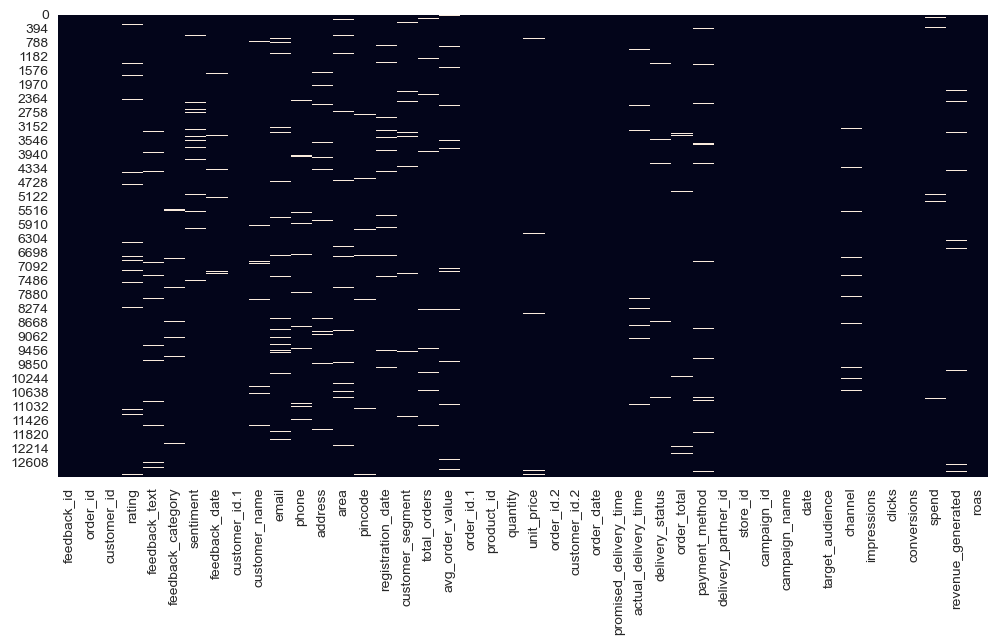

In [14]:
# missing value vizualization 
plt.figure(figsize=(12,6))

sns.heatmap(
    df_a.isnull(),
    cbar=False
)

In [15]:
# removing unnessacry coloumns 
drop_cols = [
    'customer_name',
    'email',
    'phone',
    'address',
    'feedback_text'
]

df_a.drop(
    columns=drop_cols,
    inplace=True
)

In [16]:
#handling missing values 
# finding numerical cloumns 
num_cols = df_a.select_dtypes(
    include=np.number
).columns

In [17]:
# filling with median 
for col in num_cols:
    
  df_a[col] = df_a[col].fillna(df_a[col].median())

In [18]:
# finding categorical coloumn 
cat_cols = df_a.select_dtypes(
    include='object'
).columns

In [19]:
# filling with mode 
for col in cat_cols:
    
    df_a[col].fillna(
        df_a[col].mode()[0]
    )

In [20]:
df_a.isnull().sum()

feedback_id                 0
order_id                    0
customer_id                 0
rating                      0
feedback_category         260
sentiment                 337
feedback_date             260
customer_id.1               0
area                      260
pincode                     0
registration_date         260
customer_segment          349
total_orders                0
avg_order_value             0
order_id.1                  0
product_id                  0
quantity                    0
unit_price                  0
order_id.2                  0
customer_id.2               0
order_date                  0
promised_delivery_time      0
actual_delivery_time      195
delivery_status           217
order_total                 0
payment_method            276
delivery_partner_id         0
store_id                    0
campaign_id                 0
campaign_name               0
date                        0
target_audience             0
channel                   195
impression

In [21]:
df_a.duplicated().sum()

np.int64(0)

In [22]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   feedback_id             13000 non-null  float64
 1   order_id                13000 non-null  float64
 2   customer_id             13000 non-null  float64
 3   rating                  13000 non-null  float64
 4   feedback_category       12740 non-null  object 
 5   sentiment               12663 non-null  object 
 6   feedback_date           12740 non-null  object 
 7   customer_id.1           13000 non-null  float64
 8   area                    12740 non-null  object 
 9   pincode                 13000 non-null  float64
 10  registration_date       12740 non-null  object 
 11  customer_segment        12651 non-null  object 
 12  total_orders            13000 non-null  float64
 13  avg_order_value         13000 non-null  float64
 14  order_id.1              13000 non-null

In [23]:
#invalid value detection 
df_a['rating'].describe()

count    13000.000000
mean         3.432692
std          4.518794
min        -99.000000
25%          3.000000
50%          4.000000
75%          4.000000
max         99.000000
Name: rating, dtype: float64

In [24]:
df_a[
    (df_a['rating'] < 1) |
    (df_a['rating'] > 5)
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
74,3089818.0,1.609332e+09,8791577.0,-99.0,Product Quality,Neutral,04-01-2024,32019725.0,NaN,791364.0,...,Festival Offer,28-10-2024,All,SMS,1666,508,20,3586.46,3395.18,3.25
304,9017197.0,5.012272e+09,73061709.0,-99.0,App Experience,Negative,21-09-2024,71607166.0,Rohtak,242409.0,...,Email Campaign,03-10-2024,Inactive,SMS,3373,371,17,2077.07,3507.33,3.57
333,3731240.0,6.098384e+08,54619715.0,-99.0,Delivery,Neutral,13-12-2023,70220141.0,Sambalpur,988097.0,...,New User Discount,29-09-2024,All,SMS,8057,919,64,4241.62,9942.14,1.94
414,9843205.0,4.461789e+09,79895967.0,-1.0,Customer Service,Positive,23-04-2024,79607319.0,Indore,988411.0,...,New User Discount,20-09-2024,All,Email,3762,378,97,1804.49,8799.76,3.01
479,9593233.0,7.320527e+09,83298567.0,6.0,Product Quality,Neutral,18-01-2024,50781611.0,NaN,441000.0,...,Festival Offer,13-09-2024,Premium,App,3597,238,39,2493.48,2234.52,3.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11554,6502303.0,4.932000e+09,70938353.0,99.0,App Experience,Negative,19-02-2023,70938353.0,Connaught Place,115525.0,...,Membership Drive,16-07-2023,Loyal,YouTube,9454,2002,216,7735.69,17598.80,2.28
11912,8039421.0,2.023059e+09,64912894.0,-1.0,Customer Service,Negative,21-07-2024,64912894.0,Sanganer,309413.0,...,New User Discount,06-04-2023,All,SMS,6666,329,37,1000.00,2255.94,2.26
12260,8878814.0,7.139710e+09,24770116.0,0.0,Delivery,Positive,31-03-2024,24770116.0,Dwarka,116461.0,...,Raksha Bandhan Deals,20-11-2024,New Users,Instagram,6362,1215,116,2539.22,7228.02,2.85
12641,7049712.0,8.238593e+09,50021236.0,6.0,Customer Service,Neutral,02-11-2023,50021236.0,Pratap Nagar,307106.0,...,Free Delivery Campaign,26-04-2024,Inactive,YouTube,7366,147,16,7609.15,22647.48,2.98


In [25]:
df_a[
    df_a['quantity'] <= 0
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
133,3246894.0,8.595141e+09,96511007.0,4.0,Product Quality,Positive,31-03-2024,243838.0,Visakhapatnam,865844.0,...,Email Campaign,22-10-2024,Premium,Social Media,2648,898,24,3747.00,7410.91,2.99
286,8193270.0,6.649632e+09,75640174.0,3.0,Product Quality,Neutral,30-09-2024,93867669.0,Khammam,755055.0,...,Email Campaign,05-10-2024,Inactive,App,6801,104,32,2500.47,8843.86,2.50
290,9691887.0,8.257032e+09,17805991.0,3.0,App Experience,Neutral,18-09-2024,29562254.0,Jaunpur,412653.0,...,Festival Offer,04-10-2024,New Users,Email,6759,534,22,2307.54,8842.15,3.35
511,2928147.0,1.786931e+09,1719710.0,4.0,Product Quality,Positive,29-06-2023,53399500.0,Kadapa,687962.0,...,Email Campaign,10-09-2024,New Users,Social Media,4076,273,76,4004.88,9802.82,3.49
1267,6542722.0,3.487826e+08,72415263.0,2.0,App Experience,Negative,23-09-2023,81822494.0,Sri Ganganagar,342395.0,...,Email Campaign,18-06-2024,Inactive,Email,2352,804,36,4421.23,6058.77,3.14
1412,3599242.0,8.426806e+09,11636968.0,5.0,Product Quality,Positive,17-04-2023,4200802.0,Ramgarh,860603.0,...,Referral Program,02-06-2024,Premium,SMS,3415,711,10,2963.69,5601.87,2.18
1496,9554223.0,8.293189e+09,28991365.0,1.0,Product Quality,Negative,16-10-2024,32797235.0,Guntakal,417102.0,...,Festival Offer,23-05-2024,All,Social Media,7438,381,19,3214.33,5308.32,3.74
1771,7619898.0,7.745364e+09,25585013.0,4.0,App Experience,Neutral,18-06-2023,81420960.0,Hazaribagh,367446.0,...,Email Campaign,23-04-2024,All,SMS,4905,873,31,1779.18,9278.28,1.94
2190,2138749.0,6.772651e+09,27049432.0,4.0,App Experience,Positive,15-12-2023,32540616.0,Nellore,40785.0,...,Flash Sale,07-03-2024,Premium,SMS,7538,325,63,4894.66,8779.62,2.93
2533,1817774.0,3.350349e+09,2442235.0,2.0,Product Quality,Negative,05-10-2023,2442235.0,Whitefield,381051.0,...,Membership Drive,29-01-2024,All,Email,4659,995,80,4483.58,8309.98,1.78


In [26]:
df_a[
    df_a['order_total'] < 0
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
73,344048.0,4.471162e+09,27971619.0,4.0,App Experience,NaN,06-02-2024,77220027.0,Coimbatore,387538.0,...,Weekend Special,28-10-2024,Inactive,Email,2239,183,85,1183.89,9661.81,3.17
524,6953419.0,8.686094e+09,30823988.0,5.0,Customer Service,POSITIVE,06-02-2024,96853930.0,Bhopal,349563.0,...,Festival Offer,08-09-2024,Premium,Social Media,2547,856,51,1559.86,8784.16,2.25
2534,9781710.0,2.475155e+09,13760839.0,3.0,Product Quality,Neutral,14-01-2024,13760839.0,Indira Nagar,383231.0,...,Category Promotion,29-01-2024,Inactive,SMS,3358,528,27,1294.04,4264.30,2.01
3396,4314327.0,3.239614e+09,966247.0,2.0,Customer Service,Negative,NaN,966247.0,Connaught Place,502879.0,...,Flash Sale,25-10-2023,Inactive,SMS,1101,157,26,1742.81,8934.51,2.32
4951,7488881.0,5.094990e+09,87107263.0,4.0,Product Quality,Positive,01-06-2024,87107263.0,Gomti Nagar,222629.0,...,Weekend Special,05-05-2023,Premium,App,4414,290,88,3047.24,8910.38,3.87
6181,2238679.0,2.067086e+09,27035642.0,2.0,Pricing,Neutral,01-03-2024,27035642.0,Dilsukhnagar,509161.0,...,Raksha Bandhan Deals,25-01-2024,New Users,Email,8066,1765,192,2763.86,7672.71,2.78
6758,1017486.0,4.601715e+09,13702563.0,4.0,App Experience,Positive,23-06-2023,13702563.0,Isanpur,389422.0,...,First Order Discount,26-03-2024,Loyal,App,1352,131,18,2263.25,4791.35,2.12
6882,7382325.0,5.176018e+07,35375866.0,5.0,Delivery,Neu,08-12-2023,35375866.0,OMR,605621.0,...,First Order Discount,07-04-2024,Inactive,Google Ads,5700,857,123,4510.06,12999.61,2.88
7885,4935291.0,5.099152e+09,53522940.0,4.0,Packaging,Neutral,12-05-2024,53522940.0,NaN,402756.0,...,Free Delivery Campaign,26-05-2023,Regular,Social Media,4681,201,22,2938.97,8013.04,2.73
8934,5353535.0,2.915284e+09,27939707.0,4.0,Product Quality,Positive,13-03-2023,27939707.0,Viman Nagar,419053.0,...,Flash Sale,31-03-2023,Premium,App,5663,458,60,3122.54,8511.47,2.73


In [27]:
df_a[
    df_a['revenue_generated'] < 0
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
940,7097350.0,9.670158e+09,63262519.0,3.0,App Experience,Neutral,11-03-2024,1705969.0,Surat,962834.0,...,Membership Drive,24-07-2024,New Users,SMS,3169,172,33,3977.27,-1000.0,3.73
1037,3859387.0,9.990506e+07,47590944.0,3.0,Product Quality,Negative,16-11-2023,26245432.0,Tirupati,459997.0,...,Festival Offer,13-07-2024,Premium,SMS,9050,710,50,3218.71,-1000.0,3.82
1388,8458096.0,9.933995e+09,83304571.0,4.0,Delivery,Negative,27-02-2024,31619915.0,Gandhinagar,297641.0,...,Festival Offer,04-06-2024,Inactive,SMS,7037,880,44,4910.55,-1000.0,2.16
2572,5492087.0,2.652063e+09,24144240.0,4.0,Customer Service,Neutral,22-11-2023,24144240.0,Kurla,226035.0,...,Email Campaign,25-01-2024,New Users,Social Media,3501,997,88,3639.02,-1000.0,3.48
3432,2172693.0,9.400777e+09,86487478.0,2.0,App Experience,Negative,17-11-2023,86487478.0,NaN,567226.0,...,Flash Sale,21-10-2023,New Users,App,2790,703,93,1022.62,-1000.0,1.96
4490,2859721.0,3.386091e+08,12574626.0,4.0,Customer Service,Neutral,26-10-2024,12574626.0,Chinhat,309067.0,...,Referral Program,26-06-2023,New Users,App,6243,770,21,3157.51,-1000.0,2.09
4553,5829925.0,5.415454e+09,79369660.0,4.0,Product Quality,Neutral,09-07-2024,79369660.0,Chandkheda,567264.0,...,Referral Program,19-06-2023,New Users,Email,9834,473,89,2410.94,-1000.0,2.41
5612,7630509.0,2.819854e+09,58834613.0,2.0,Customer Service,Negative,14-06-2023,58834613.0,Noida,112428.0,...,Festival Offer,26-08-2023,New Users,Push Notification,9292,2122,249,2554.74,-1000.0,2.53
6698,1303422.0,5.597310e+09,25584607.0,3.0,Product Quality,NaN,21-03-2024,25584607.0,Malviya Nagar,302939.0,...,Festive Essentials Sale,03-07-2023,Premium,App,2606,465,51,3753.70,-1000.0,3.37
6926,2787301.0,2.201768e+09,15558146.0,5.0,App Experience,Positive,06-04-2024,15558146.0,Howrah,702140.0,...,Raksha Bandhan Deals,09-08-2024,Loyal,SMS,6336,1089,116,1833.33,-1000.0,2.70


In [29]:
# conversion validation (converstion should never exceed clicks )
df_a[
    df_a['conversions']
    >
    df_a['clicks']
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas


In [30]:
# click validation 
df_a[
    df_a['clicks']
    >
    df_a['impressions']
]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
489,9606913.0,9.328057e+09,81229704.0,4.0,App Experience,Positive,14-08-2024,26863280.0,Rajkot,80555.0,...,Flash Sale,12-09-2024,All,App,1,920,73,4847.74,2188.06,2.42
535,1678914.0,1.577085e+09,74682740.0,1.0,Delivery,Negative,22-09-2023,18229949.0,Danapur,397135.0,...,Membership Drive,07-09-2024,All,Email,1,761,83,2725.14,6312.76,3.54
1062,7638910.0,2.241930e+09,66943324.0,1.0,Customer Service,Negative,05-11-2023,14479168.0,Rewa,854880.0,...,New User Discount,10-07-2024,Inactive,App,0,809,96,3110.10,6764.98,2.06
1316,6846846.0,4.045614e+09,61763552.0,3.0,Customer Service,Neutral,09-08-2023,76602787.0,Mehsana,856383.0,...,Festival Offer,12-06-2024,All,SMS,2,834,32,3486.68,3409.51,2.15
1483,998290.0,6.497070e+09,52672659.0,3.0,Delivery,NaN,10-04-2024,46541905.0,Udaipur,412653.0,...,Email Campaign,25-05-2024,New Users,Email,2,780,75,1220.27,4263.89,2.55
1634,2566002.0,6.031122e+09,28603182.0,1.0,Customer Service,Negative,NaN,90346920.0,Satara,677618.0,...,Category Promotion,08-05-2024,New Users,Social Media,1,523,61,4545.58,9823.07,2.11
1686,5257765.0,1.234693e+09,76971644.0,5.0,App Experience,Positive,19-03-2024,29415527.0,Pudukkottai,675974.0,...,Flash Sale,02-05-2024,Inactive,Email,0,462,48,2292.37,3003.05,2.68
1738,2738650.0,9.410752e+09,44859592.0,4.0,Product Quality,Neutral,25-07-2024,60495351.0,Srikakulam,246691.0,...,Weekend Special,26-04-2024,New Users,Social Media,0,195,91,1545.18,9459.01,3.92
2009,167681.0,7.167417e+08,43052303.0,1.0,Customer Service,Negative,15-10-2024,64298209.0,Jodhpur,412653.0,...,Festival Offer,27-03-2024,New Users,Email,0,732,92,4988.66,4619.99,1.99
2199,2438647.0,6.891101e+08,84161531.0,5.0,Product Quality,Positive,03-05-2023,90448312.0,Panihati,753285.0,...,Flash Sale,06-03-2024,New Users,App,0,501,28,3228.33,7505.28,1.77


In [31]:
# removing rows because clicks is greater than impression 
df_a =df_a[df_a['clicks']<=df_a['impressions']]

In [32]:
# category standardization 
df_a['sentiment'].unique()

array(['Neutral', 'Negative', 'Positive', nan, '0', 'mixed', 'neg', 'Neu',
       'POSITIVE', 'neutral '], dtype=object)

In [33]:
df_a['sentiment'] = (
    df_a['sentiment']
    .str.title()
    .str.strip()
)

In [34]:
df_a['delivery_status'].unique()

array(['On Time', 'Slightly Delayed', 'Significantly Delayed', nan,
       'Pending', 'Unknown', '-', 'on time', 'DELIVERED', 'delayed',
       'Returned', 'Cancelled'], dtype=object)

In [35]:
df_a['delivery_status'] = (
    df_a['delivery_status']
    .str.title()
    .str.strip()
)

In [36]:
df_a['customer_segment'].unique()

array(['Premium', 'Inactive', 'Regular', nan, 'New', 'unknown', 'Silver',
       'GOLD', '-', 'newuser', 'vip', 'Loyal', 'VIP'], dtype=object)

In [37]:
df_a['customer_segment'] = (
    df_a['customer_segment']
    .str.title()
    .str.strip()
)

In [38]:
# outlier detection 
num_cols = df_a.select_dtypes(
    include=np.number
).columns


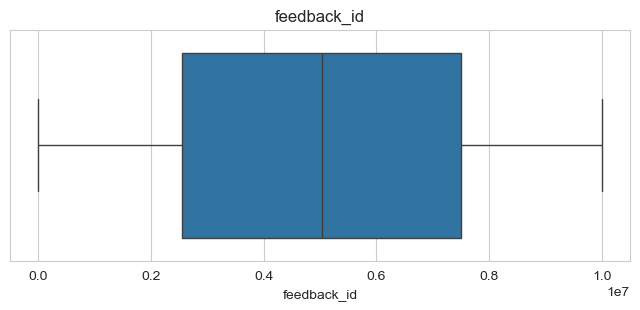

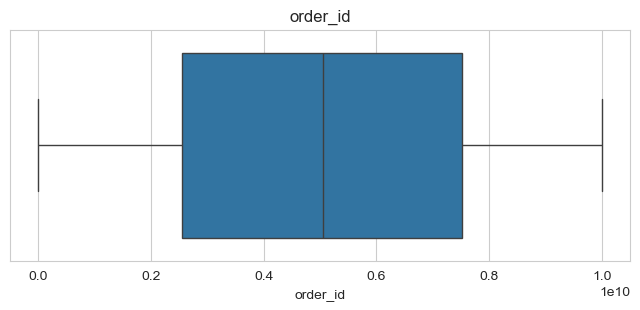

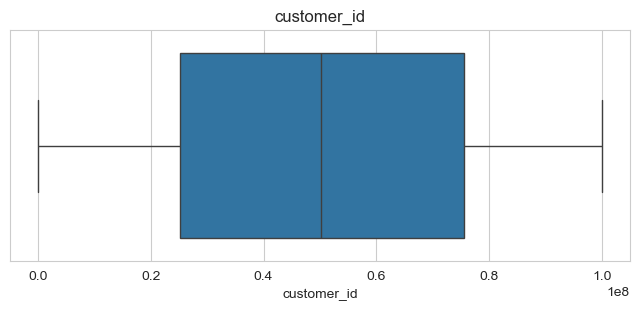

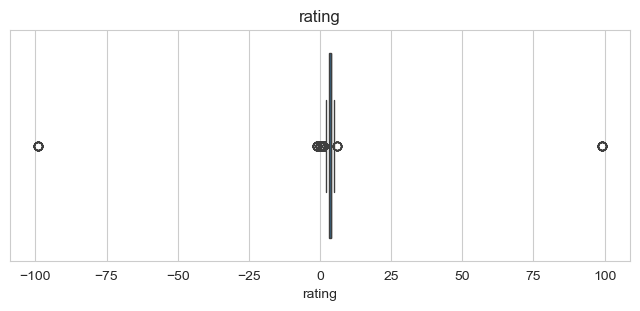

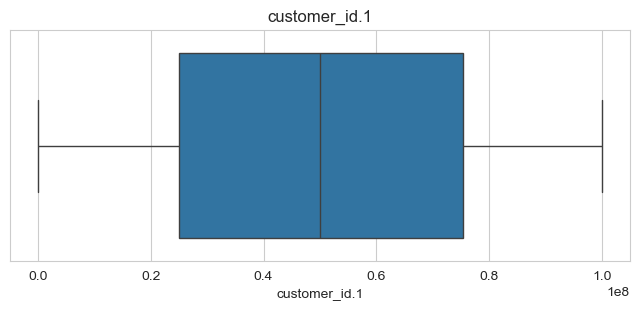

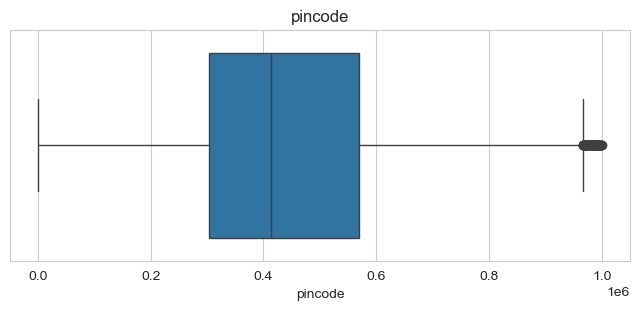

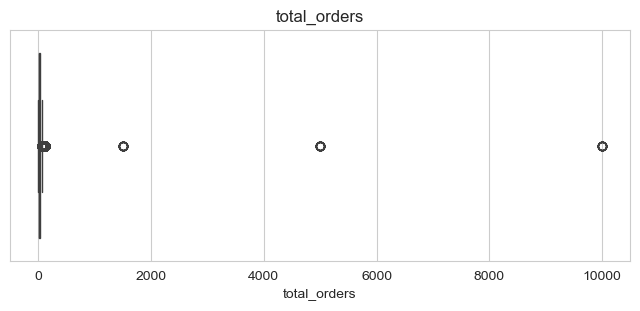

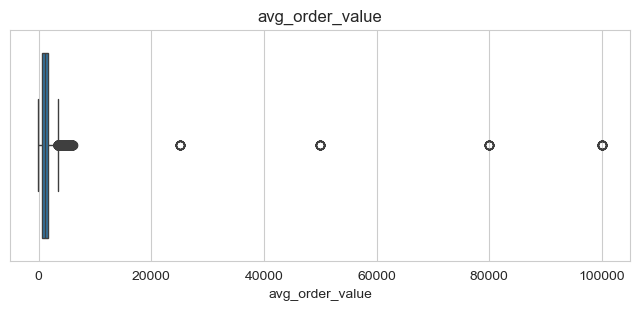

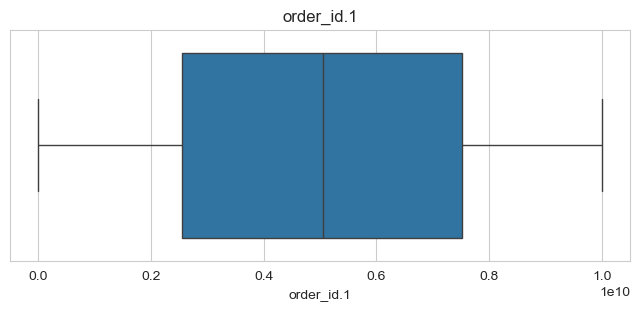

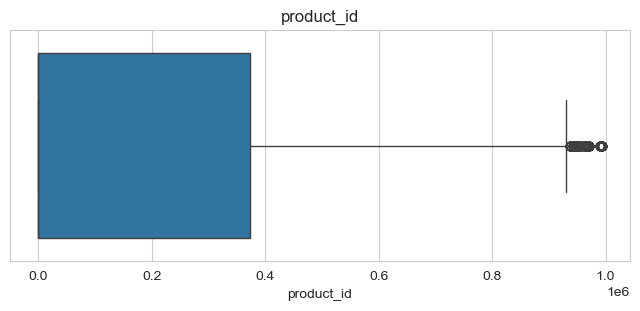

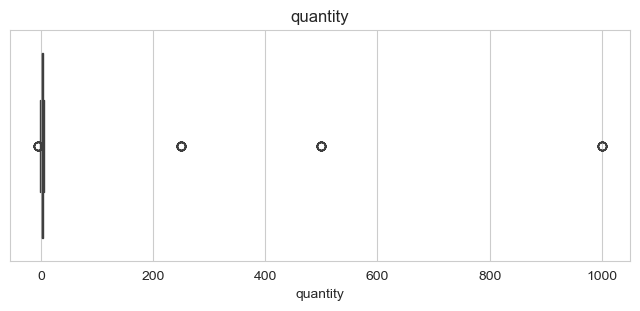

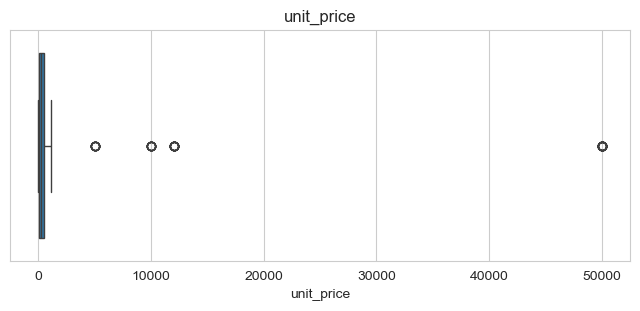

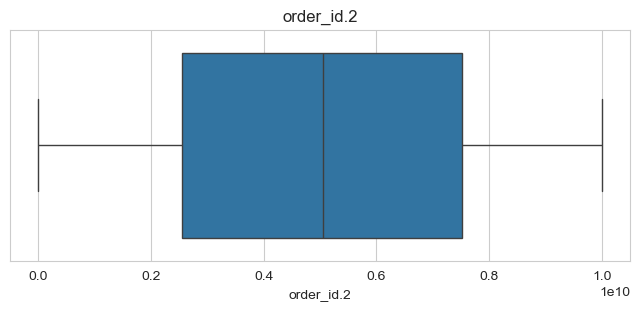

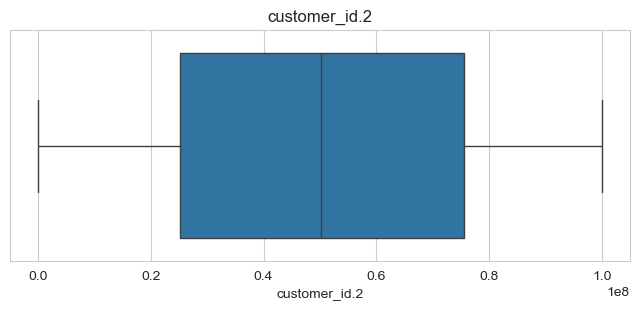

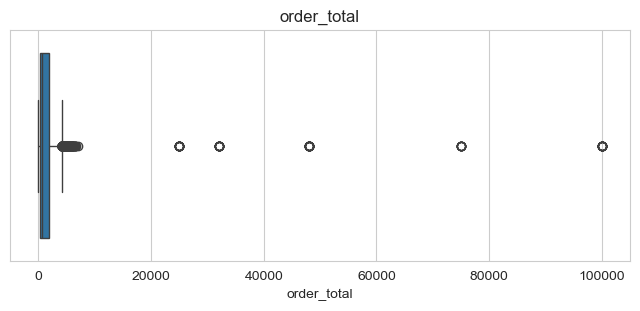

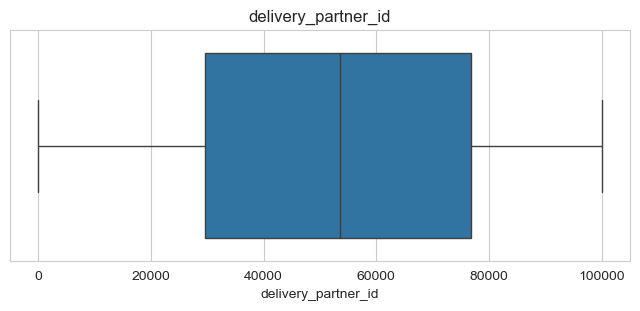

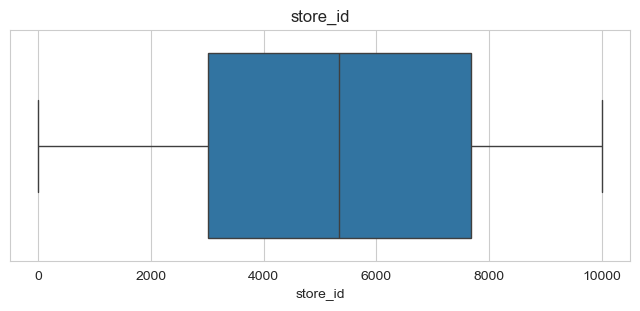

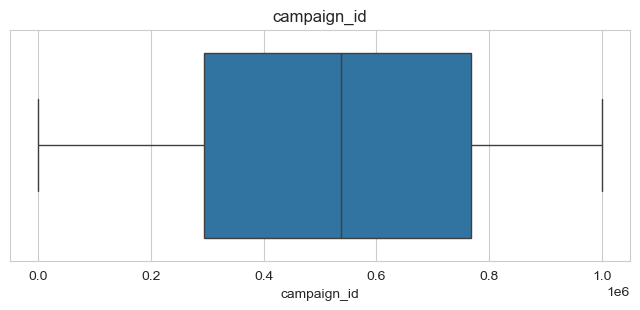

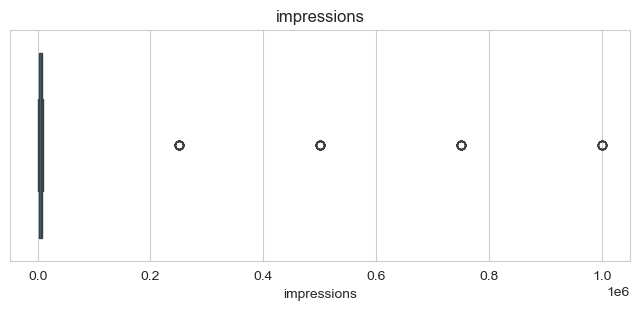

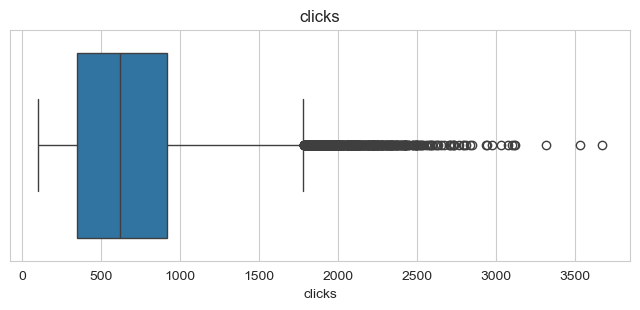

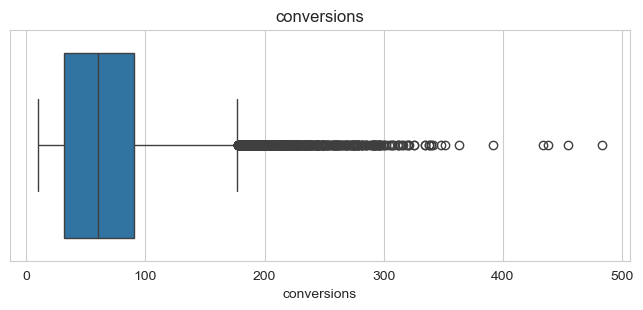

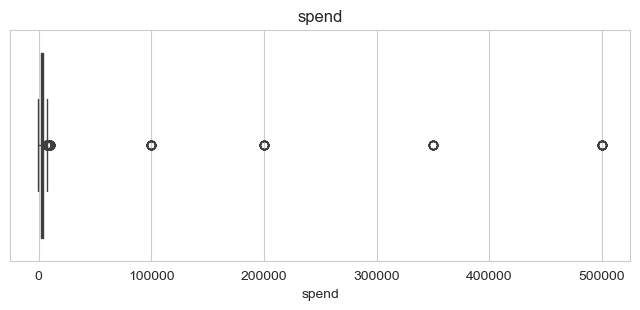

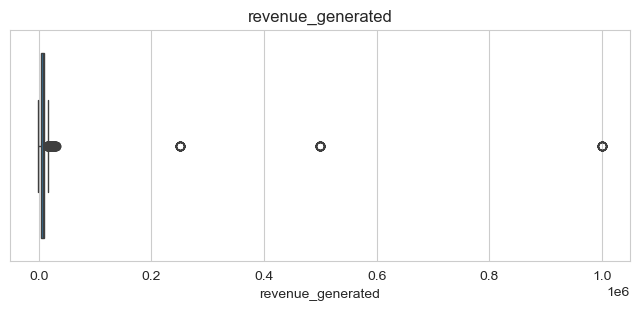

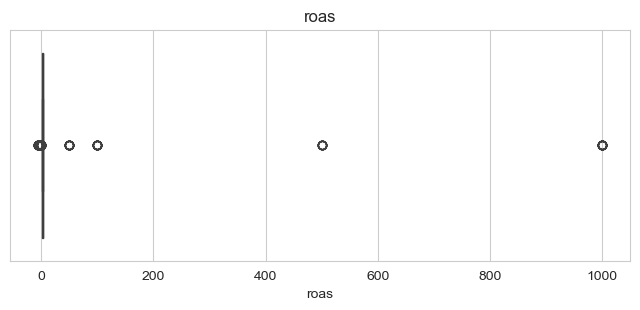

In [39]:
for col in num_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df_a[col]
    )

    plt.title(col)

    plt.show()

In [40]:
#for order_total
Q1 = df_a['order_total'].quantile(0.25)

Q3 = df_a['order_total'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print(lower, upper)

-2134.71375 4180.296249999999


In [41]:
outliers = df_a[
    (df_a['order_total'] < lower) |
    (df_a['order_total'] > upper)
]

len(outliers)

487

In [42]:
outliers[['order_total']].sort_values(
    by='order_total',
    ascending=False
).head(20)

,order_total
12996,99999.0
813,99999.0
7360,99999.0
8830,99999.0
9223,99999.0
9657,99999.0
9852,99999.0
7571,99999.0
9956,99999.0
8271,99999.0


In [43]:
df_a['order_total'].describe()

count    12948.000000
mean      1428.854737
std       4339.611932
min        -50.000000
25%        233.415000
50%        639.375000
75%       1812.167500
max      99999.000000
Name: order_total, dtype: float64

In [44]:
#Identify Suspicious Values
df_a[df_a['order_total'] > 20000]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
176,9347337.0,8.787105e+09,81822935.0,4.0,Delivery,Positive,07-05-2024,22321208.0,Ballia,740752.0,...,Category Promotion,17-10-2024,Inactive,Social Media,7936,927,82,4318.97,7069.93,3.56
232,8510571.0,2.055388e+09,119099.0,4.0,Product Quality,Positive,23-06-2023,20951294.0,Anantapur,766714.0,...,Email Campaign,11-10-2024,Premium,App,1141,741,30,4295.89,6285.19,2.35
301,4258919.0,4.706569e+09,68016312.0,5.0,Delivery,Positive,27-07-2023,80476444.0,Eluru,868809.0,...,Membership Drive,03-10-2024,New Users,App,9200,521,19,3255.93,3768.57,2.68
813,5945755.0,7.305872e+09,96629034.0,4.0,App Experience,NaN,11-09-2024,84937877.0,Guntur,711210.0,...,Flash Sale,07-08-2024,All,App,4722,950,88,3983.59,7305.40,2.95
1141,2620357.0,8.979477e+09,49970560.0,4.0,Customer Service,Neutral,06-06-2023,43459807.0,Khammam,886183.0,...,Email Campaign,02-07-2024,Premium,App,7675,417,88,2789.71,9339.14,2.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11957,7439630.0,2.747851e+09,49881918.0,5.0,Delivery,Positive,13-04-2024,49881918.0,Hazratganj,222520.0,...,App Push Notification,01-09-2023,New Users,SMS,4042,690,72,3314.83,7625.52,2.30
12278,5647122.0,7.977037e+07,5048715.0,5.0,Packaging,Positive,14-11-2023,5048715.0,Vibhuti Khand,221241.0,...,Flash Sale,18-10-2023,All,Email,7094,719,89,2014.44,6436.03,3.19
12615,5237893.0,4.860875e+09,5991361.0,4.0,Customer Service,Neutral,05-07-2023,5991361.0,Jagatpura,307586.0,...,Instant Delivery Offer,31-07-2023,All,SMS,2108,159,10,1369.30,4793.46,3.50
12904,9939867.0,4.508231e+09,93186420.0,5.0,Product Quality,Positive,20-12-2023,93186420.0,Howrah,705770.0,...,First Order Discount,05-02-2024,Inactive,Instagram,7108,1520,119,5392.67,17327.13,3.21


In [45]:
df_a['order_total'] = df_a['order_total'].replace(
    [75000, 99999],
    np.nan
)

In [46]:
df_a['order_total'].fillna(
    df_a['order_total'].median()
)

0        3197.070
1         976.550
2         839.050
3         440.230
4        2526.680
           ...   
12995     694.730
12996     639.375
12997     300.510
12998      41.610
12999    1292.950
Name: order_total, Length: 12948, dtype: float64

In [47]:
df_a['order_total'].describe()

count    12928.000000
mean      1289.899763
std       2477.926597
min        -50.000000
25%        232.525000
50%        639.375000
75%       1804.115000
max      48000.000000
Name: order_total, dtype: float64

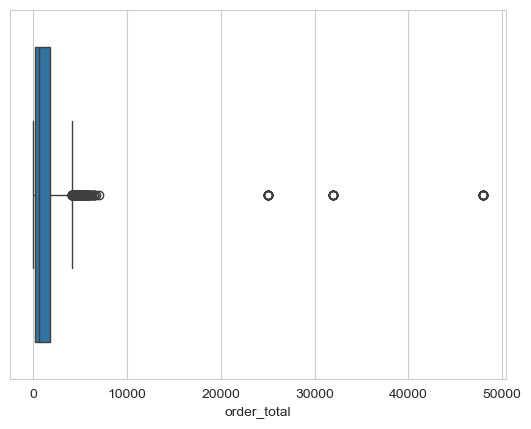

In [48]:
sns.boxplot(x=df_a['order_total'])
plt.show()

In [49]:
# outlier detection for avg_order_value and its handling 
df_a['avg_order_value'].describe()

count    12948.000000
mean      1550.512498
std       4638.455698
min       -100.000000
25%        539.220000
50%       1035.560000
75%       1683.715000
max      99999.000000
Name: avg_order_value, dtype: float64

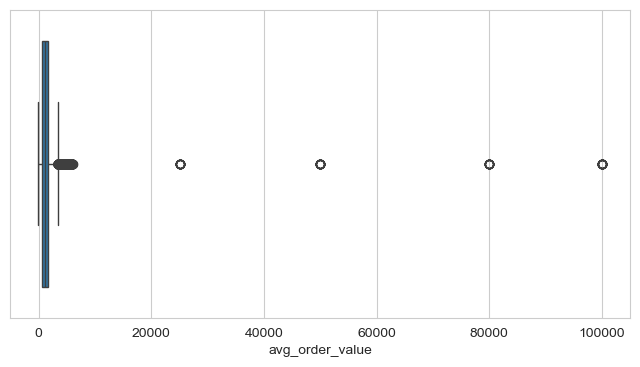

In [50]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_a['avg_order_value'])
plt.show()

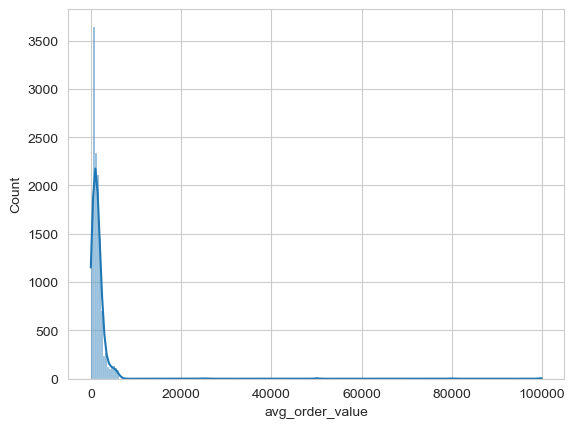

In [51]:
sns.histplot(df_a['avg_order_value'], kde=True)
plt.show()

In [52]:
df_a['avg_order_value'].sort_values(
    ascending=False
).head(20)

9046     99999.0
10599    99999.0
7780     99999.0
8361     99999.0
4652     99999.0
7358     99999.0
2672     99999.0
4112     99999.0
8749     99999.0
1585     99999.0
3774     99999.0
2271     99999.0
2008     99999.0
3403     99999.0
11120    99999.0
7058     99999.0
9197     99999.0
2260     80000.0
1036     80000.0
3631     80000.0
Name: avg_order_value, dtype: float64

In [53]:
# calculating iqr for this 
Q1 = df_a['avg_order_value'].quantile(0.25)

Q3 = df_a['avg_order_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-1177.5224999999998
3400.4574999999995


In [54]:
outliers = df_a[
    (df_a['avg_order_value'] < lower) |
    (df_a['avg_order_value'] > upper)
]

len(outliers)

733

In [55]:
# capping outlier ( giving max limit value )
df_a['avg_order_value'] = np.where(
    df_a['avg_order_value'] > upper,
    upper,
    df_a['avg_order_value']
)

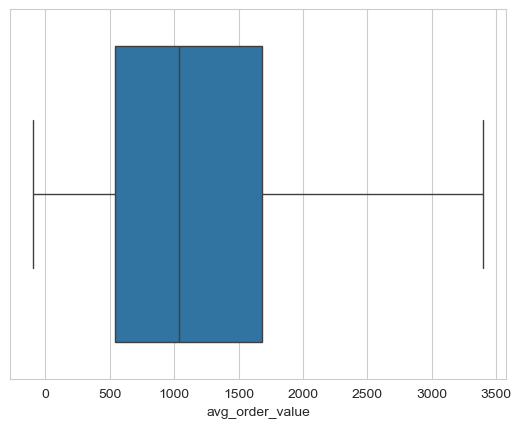

In [56]:
sns.boxplot(x=df_a['avg_order_value'])
plt.show()

In [57]:
# outlier detection for Roas
df_a['roas'].describe()

count    12948.000000
mean         4.218992
std         35.145306
min         -5.000000
25%          2.240000
50%          2.700000
75%          3.190000
max        999.000000
Name: roas, dtype: float64

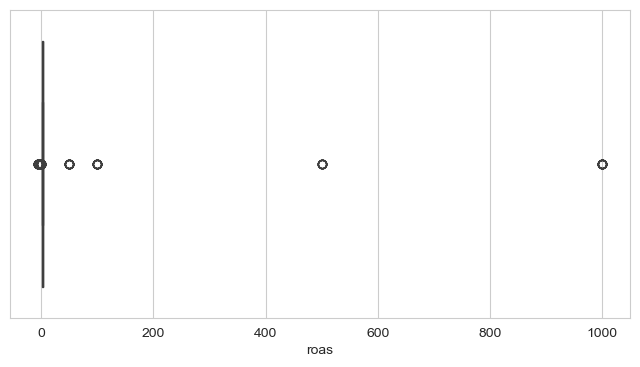

In [58]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_a['roas'])
plt.show()

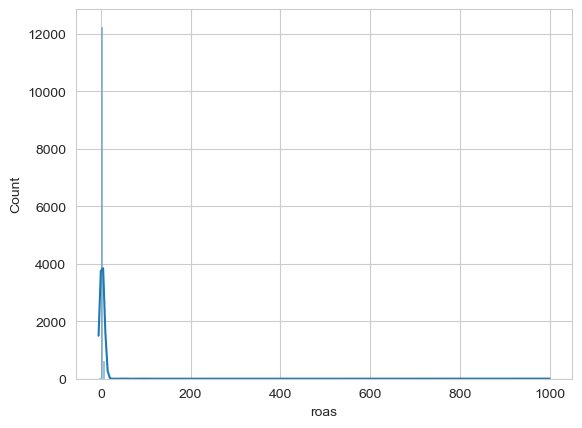

In [59]:
sns.histplot(df_a['roas'], kde=True)
plt.show()

In [60]:
df_a['roas'].sort_values(
    ascending=False
).head(20)

3049     999.0
7120     999.0
11870    999.0
1801     999.0
5360     999.0
192      999.0
6985     999.0
3737     999.0
7825     999.0
174      999.0
2916     999.0
1027     999.0
12987    999.0
11519    999.0
8967     500.0
1919     500.0
12059    500.0
1578     500.0
4878     500.0
3774     500.0
Name: roas, dtype: float64

In [61]:
Q1 = df_a['roas'].quantile(0.25)

Q3 = df_a['roas'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: 0.8150000000000006
Upper: 4.614999999999999


In [62]:
outliers = df_a[
    (df_a['roas'] < lower) |
    (df_a['roas'] > upper)
]

len(outliers)

90

In [63]:
df_a[
    df_a['roas'] > upper
]['roas'].sort_values(
    ascending=False
).head(20)

174      999.0
2916     999.0
11870    999.0
11519    999.0
7825     999.0
7120     999.0
6985     999.0
192      999.0
5360     999.0
3737     999.0
3049     999.0
12987    999.0
1027     999.0
1801     999.0
1578     500.0
1252     500.0
3637     500.0
3774     500.0
12059    500.0
4878     500.0
Name: roas, dtype: float64

In [64]:
# capping the roas 
df_a['roas'] = np.where(
    df_a['roas'] > upper,
    upper,
    df_a['roas']
)

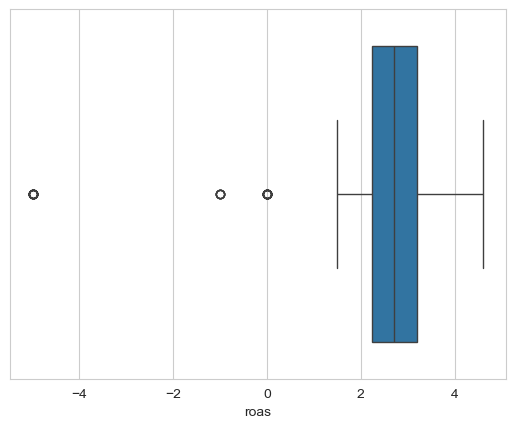

In [65]:
sns.boxplot(x=df_a['roas'])
plt.show()

In [66]:
df_a['quantity'].describe()

count    12948.000000
mean         3.628746
std         33.908156
min         -5.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: quantity, dtype: float64

In [67]:
df_a[df_a['quantity'] <= 0]

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
133,3246894.0,8.595141e+09,96511007.0,4.0,Product Quality,Positive,31-03-2024,243838.0,Visakhapatnam,865844.0,...,Email Campaign,22-10-2024,Premium,Social Media,2648,898,24,3747.00,7410.91,2.99
286,8193270.0,6.649632e+09,75640174.0,3.0,Product Quality,Neutral,30-09-2024,93867669.0,Khammam,755055.0,...,Email Campaign,05-10-2024,Inactive,App,6801,104,32,2500.47,8843.86,2.50
290,9691887.0,8.257032e+09,17805991.0,3.0,App Experience,Neutral,18-09-2024,29562254.0,Jaunpur,412653.0,...,Festival Offer,04-10-2024,New Users,Email,6759,534,22,2307.54,8842.15,3.35
511,2928147.0,1.786931e+09,1719710.0,4.0,Product Quality,Positive,29-06-2023,53399500.0,Kadapa,687962.0,...,Email Campaign,10-09-2024,New Users,Social Media,4076,273,76,4004.88,9802.82,3.49
1267,6542722.0,3.487826e+08,72415263.0,2.0,App Experience,Negative,23-09-2023,81822494.0,Sri Ganganagar,342395.0,...,Email Campaign,18-06-2024,Inactive,Email,2352,804,36,4421.23,6058.77,3.14
1412,3599242.0,8.426806e+09,11636968.0,5.0,Product Quality,Positive,17-04-2023,4200802.0,Ramgarh,860603.0,...,Referral Program,02-06-2024,Premium,SMS,3415,711,10,2963.69,5601.87,2.18
1496,9554223.0,8.293189e+09,28991365.0,1.0,Product Quality,Negative,16-10-2024,32797235.0,Guntakal,417102.0,...,Festival Offer,23-05-2024,All,Social Media,7438,381,19,3214.33,5308.32,3.74
1771,7619898.0,7.745364e+09,25585013.0,4.0,App Experience,Neutral,18-06-2023,81420960.0,Hazaribagh,367446.0,...,Email Campaign,23-04-2024,All,SMS,4905,873,31,1779.18,9278.28,1.94
2190,2138749.0,6.772651e+09,27049432.0,4.0,App Experience,Positive,15-12-2023,32540616.0,Nellore,40785.0,...,Flash Sale,07-03-2024,Premium,SMS,7538,325,63,4894.66,8779.62,2.93
2533,1817774.0,3.350349e+09,2442235.0,2.0,Product Quality,Negative,05-10-2023,2442235.0,Whitefield,381051.0,...,Membership Drive,29-01-2024,All,Email,4659,995,80,4483.58,8309.98,1.78


In [68]:
df_a['quantity'].sort_values(
    ascending=False
).head(20)

6130     1000.0
2000     1000.0
11104    1000.0
1512     1000.0
11953    1000.0
7770     1000.0
9817     1000.0
9918     1000.0
10002    1000.0
10020    1000.0
5432      500.0
1904      500.0
3226      500.0
4305      500.0
8195      500.0
5648      500.0
10104     500.0
1724      500.0
5491      500.0
5997      500.0
Name: quantity, dtype: float64

In [69]:
Q1 = df_a['quantity'].quantile(0.25)

Q3 = df_a['quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-2.0
6.0


In [70]:
outliers = df_a[
    (df_a['quantity'] < lower) |
    (df_a['quantity'] > upper)
]

len(outliers)

57

In [71]:
df_a['quantity'] = df_a['quantity'].replace(
    [500, 1000],
    np.nan
)

In [72]:
df_a['quantity'].fillna(
    df_a['quantity'].median()
)

0        3.0
1        1.0
2        2.0
3        1.0
4        2.0
        ... 
12995    4.0
12996    2.0
12997    2.0
12998    1.0
12999    3.0
Name: quantity, Length: 12948, dtype: float64

In [73]:
#Invalid Data Format Handling
date_cols = [
    'feedback_date',
    'registration_date',
    'order_date',
    'date'
]

df_a[date_cols].head()

,feedback_date,registration_date,order_date,date
0,17-07-2024,13-05-2023,17-07-2024 08:34,05-11-2024
1,28-05-2024,18-06-2024,28-05-2024 13:14,05-11-2024
2,23-09-2024,25-09-2024,23-09-2024 13:07,05-11-2024
3,24-11-2023,04-10-2023,24-11-2023 16:16,05-11-2024
4,20-11-2023,22-03-2024,20-11-2023 05:00,05-11-2024


In [74]:
df_a['feedback_date'].head()

0    17-07-2024
1    28-05-2024
2    23-09-2024
3    24-11-2023
4    20-11-2023
Name: feedback_date, dtype: object

In [75]:
for col in date_cols:
    df_a[col] = pd.to_datetime(
        df_a[col],
        dayfirst=True,
        errors='coerce'
    )

In [76]:
df_a[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 12948 entries, 0 to 12999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   feedback_date      12689 non-null  datetime64[ns]
 1   registration_date  12613 non-null  datetime64[ns]
 2   order_date         12948 non-null  datetime64[ns]
 3   date               12948 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 505.8 KB


In [77]:
# data validation 
# checking negative financial values 
(df_a['revenue_generated']<0).sum()

np.int64(20)

In [78]:
df_a[df_a['revenue_generated'] < 0][[
    'campaign_name',
    'spend',
    'revenue_generated',
    'conversions',
    'roas'
]]

,campaign_name,spend,revenue_generated,conversions,roas
940,Membership Drive,3977.27,-1000.0,33,3.73
1037,Festival Offer,3218.71,-1000.0,50,3.82
1388,Festival Offer,4910.55,-1000.0,44,2.16
2572,Email Campaign,3639.02,-1000.0,88,3.48
3432,Flash Sale,1022.62,-1000.0,93,1.96
4490,Referral Program,3157.51,-1000.0,21,2.09
4553,Referral Program,2410.94,-1000.0,89,2.41
5612,Festival Offer,2554.74,-1000.0,249,2.53
6698,Festive Essentials Sale,3753.70,-1000.0,51,3.37
6926,Raksha Bandhan Deals,1833.33,-1000.0,116,2.70


In [79]:
df_a = df_a[df_a['revenue_generated'] >= 0]

In [80]:
# check spend
(df_a['spend']<0).sum()

np.int64(21)

In [81]:
df_a[df_a['spend'] < 0][[
    'campaign_name',
    'spend',
    'revenue_generated',
    'roas'
]]

,campaign_name,spend,revenue_generated,roas
38,Festival Offer,-500.0,9687.96,2.20
129,Flash Sale,-500.0,4725.54,1.63
145,Weekend Special,-500.0,8434.35,2.15
313,Email Campaign,-500.0,3563.69,1.60
394,Email Campaign,-500.0,4568.42,3.11
1756,Weekend Special,-500.0,3010.34,3.40
1950,App Push Notification,-500.0,2501.33,1.82
3854,Festival Offer,-500.0,4557.93,1.58
4695,App Push Notification,-500.0,4534.84,2.40
5481,Raksha Bandhan Deals,-500.0,5813.07,1.87


In [82]:
(df_a['order_total']<0).sum()

np.int64(13)

In [83]:
# validating delivery status 
df_a['delivery_status'].unique()

array(['On Time', 'Slightly Delayed', 'Significantly Delayed', nan,
       'Pending', 'Unknown', '-', 'Delivered', 'Delayed', 'Returned',
       'Cancelled'], dtype=object)

In [84]:
# validating date range 

df_a['order_date'].min()

Timestamp('2023-01-01 07:59:00')

In [85]:
df_a['order_date'].max()

Timestamp('2024-11-30 23:51:00')

STEP 9 - FEATURE ENGINEERING 

In [86]:
#create delivery delay 
df_a['actual_delivery_time'] = pd.to_datetime(df_a['actual_delivery_time'])
df_a['promised_delivery_time'] = pd.to_datetime(df_a['promised_delivery_time'])

df_a['delay_minutes'] = (
    df_a['actual_delivery_time'] - df_a['promised_delivery_time']
).dt.total_seconds() / 60

# tells how many minustes late delivery happend 

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\4225366318.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_a['actual_delivery_time'] = pd.to_datetime(df_a['actual_delivery_time'])
C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\4225366318.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_a['promised_delivery_time'] = pd.to_datetime(df_a['promised_delivery_time'])


In [87]:
df_a['delay_minutes'].describe()

count    12735.000000
mean         2.037063
std          8.638357
min        -30.000000
25%         -3.000000
50%          0.000000
75%          4.000000
max         40.000000
Name: delay_minutes, dtype: float64

<Axes: xlabel='delay_minutes', ylabel='Count'>

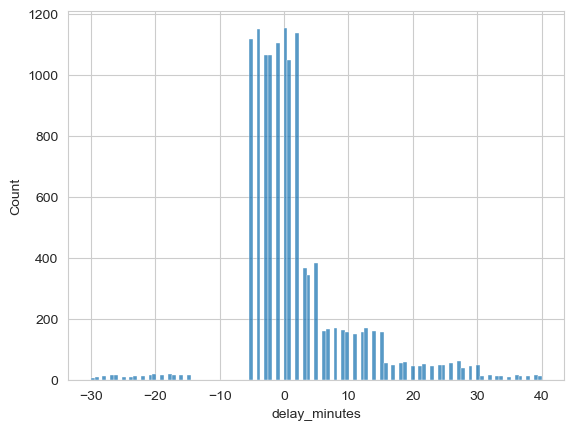

In [88]:
sns.histplot(df_a['delay_minutes'])

In [89]:
# CREATING SLA BREACH FLAG 
df_a['sla_breach'] = np.where (
    df_a['delay_minutes']>0,
    1,
    0
)

In [90]:
df_a['sla_breach'].mean()*100 # percentage of late deliveries 

np.float64(45.14232673267327)

In [91]:
# creating profit feature 
df_a['profit'] = (
    df_a['revenue_generated']
    - df_a['spend']
)

In [92]:
df_a['revenue_generated'] = df_a[
    'revenue_generated'
].replace(
    [500000, 999999],
    np.nan
)

In [93]:
df_a['revenue_generated'].fillna(
    df_a['revenue_generated'].median(),
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3536743605.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['revenue_generated'].fillna(


In [94]:
df_a['profit'].describe()

count     12928.000000
mean       5577.833244
std       43169.988734
min     -497225.750000
25%        2278.737500
50%        4128.875000
75%        6307.387500
max      998847.360000
Name: profit, dtype: float64

In [95]:
df_a['profit'].sort_values(
    ascending=False
).head(20)

7367     998847.36
823      998725.91
5908     998702.26
5069     998390.98
6490     998347.25
12762    998100.40
6838     997279.69
1253     996888.48
2852     996886.11
6418     996753.96
7325     996629.93
11908    995986.64
7160     992515.15
8419     498892.06
7233     498830.46
1944     498751.50
11797    497924.34
8701     497444.82
8488     497383.52
11843    497129.56
Name: profit, dtype: float64

In [96]:
df_a['revenue_generated'].value_counts().head(30)

revenue_generated
7000.77      231
1.00          18
250000.00     16
0.00          13
4019.38        3
4449.49        2
8440.25        2
4051.59        2
5970.43        2
9068.41        2
9022.58        2
6438.12        2
11185.29       2
3746.48        2
4494.17        2
16891.28       2
11062.92       2
3459.66        2
8706.56        2
6006.35        2
5099.12        2
9698.04        2
3994.19        2
7292.98        2
3579.80        2
14872.19       2
4691.39        2
7943.16        2
5417.93        2
7969.46        2
Name: count, dtype: int64

In [97]:
df_a['revenue_generated'] = df_a[
    'revenue_generated'
].replace(
    250000,
    np.nan
)

In [98]:
df_a['revenue_generated'].fillna(
    df_a['revenue_generated'].median(),
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3536743605.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['revenue_generated'].fillna(


In [99]:
df_a['profit'].sort_values(
    ascending=False
).head(20)

7367     998847.36
823      998725.91
5908     998702.26
5069     998390.98
6490     998347.25
12762    998100.40
6838     997279.69
1253     996888.48
2852     996886.11
6418     996753.96
7325     996629.93
11908    995986.64
7160     992515.15
8419     498892.06
7233     498830.46
1944     498751.50
11797    497924.34
8701     497444.82
8488     497383.52
11843    497129.56
Name: profit, dtype: float64

In [100]:
df_a[
    df_a['revenue_generated'] == 1
]


,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,channel,impressions,clicks,conversions,spend,revenue_generated,roas,delay_minutes,sla_breach,profit
545,4619026.0,4.360255e+09,15529446.0,2.0,App Experience,Negative,2023-05-14,55552600.0,Gorakhpur,81284.0,...,Email,3019,413,59,3136.90,1.0,2.34,8.0,1,-3135.90
905,7726560.0,5.302956e+09,97111069.0,4.0,Delivery,Positive,2024-01-22,15796277.0,Loni,223700.0,...,SMS,9631,878,48,0.50,1.0,3.82,0.0,0,0.50
1126,1233739.0,3.960981e+09,52417972.0,5.0,Customer Service,Positive,2024-06-21,31708103.0,Gudivada,479673.0,...,App,7636,748,93,4831.10,1.0,3.70,11.0,1,-4830.10
1225,4994524.0,1.013631e+09,85763665.0,1.0,Product Quality,Negative,2024-05-19,35156679.0,Etawah,954583.0,...,SMS,2920,756,38,2289.65,1.0,1.80,18.0,1,-2288.65
2180,8817304.0,1.553627e+09,6579892.0,3.0,Product Quality,Negative,2024-10-26,48167795.0,Visakhapatnam,567196.0,...,Social Media,4488,931,71,2935.19,1.0,1.68,5.0,1,-2934.19
3482,4265813.0,6.353755e+09,41972994.0,3.0,Delivery,Negative,2024-02-12,41972994.0,Pimple Saudagar,561686.0,...,Social Media,3237,205,25,3337.31,1.0,3.14,3.0,1,-3336.31
3869,1668566.0,7.980887e+08,89699655.0,5.0,Customer Service,Positive,2023-09-07,89699655.0,SG Highway,604703.0,...,Social Media,4339,483,16,3644.89,1.0,3.53,6.0,1,-3643.89
4892,9553826.0,6.270464e+09,35434373.0,2.0,Delivery,Negative,2023-10-03,35434373.0,Perambur,709309.0,...,SMS,1181,748,47,1510.24,1.0,3.05,-4.0,0,-1509.24
5077,4119147.0,4.771069e+09,13557652.0,3.0,Product Quality,Neutral,2024-09-10,13557652.0,Indira Nagar,223379.0,...,Email,6947,475,99,2458.85,1.0,2.83,0.0,0,-2457.85
5337,3888030.0,6.931681e+09,44253902.0,1.0,Customer Service,Negative,2024-06-04,44253902.0,Secunderabad,563052.0,...,SMS,6417,746,97,3803.80,1.0,2.48,2.0,1,-3802.80


In [101]:
df_a['profit'].describe()

count     12928.000000
mean       5577.833244
std       43169.988734
min     -497225.750000
25%        2278.737500
50%        4128.875000
75%        6307.387500
max      998847.360000
Name: profit, dtype: float64

In [102]:
df_a.nsmallest(
    20,
    'profit'
)[[
    'campaign_name',
    'spend',
    'revenue_generated',
    'roas',
    'profit'
]]

,campaign_name,spend,revenue_generated,roas,profit
6528,First Order Discount,500000.0,2774.25,1.50,-497225.75
4593,Flash Sale,500000.0,3045.82,3.41,-496954.18
4324,Membership Drive,500000.0,3792.75,2.50,-496207.25
3064,Membership Drive,500000.0,4271.08,3.03,-495728.92
5266,Weekend Special,500000.0,5412.99,1.99,-494587.01
4132,Weekend Special,500000.0,5603.77,3.27,-494396.23
2135,Festival Offer,500000.0,6781.99,3.68,-493218.01
10090,Free Delivery Campaign,500000.0,6782.21,2.96,-493217.79
7900,Diwali Bonanza,500000.0,7000.77,2.41,-492999.23
3227,Category Promotion,500000.0,8422.26,1.74,-491577.74


In [103]:
df_a['spend'] = df_a['spend'].replace(
    [350000, 500000],
    np.nan
)

In [104]:
df_a['spend'].fillna(
    df_a['spend'].median(),
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3127122416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['spend'].fillna(


In [105]:
df_a['profit'].describe()

count     12928.000000
mean       5577.833244
std       43169.988734
min     -497225.750000
25%        2278.737500
50%        4128.875000
75%        6307.387500
max      998847.360000
Name: profit, dtype: float64

In [106]:
df_a.nsmallest(
    20,
    'profit'
)[[
    'campaign_name',
    'spend',
    'revenue_generated',
    'roas',
    'profit'
]]

,campaign_name,spend,revenue_generated,roas,profit
6528,First Order Discount,3047.24,2774.25,1.50,-497225.75
4593,Flash Sale,3047.24,3045.82,3.41,-496954.18
4324,Membership Drive,3047.24,3792.75,2.50,-496207.25
3064,Membership Drive,3047.24,4271.08,3.03,-495728.92
5266,Weekend Special,3047.24,5412.99,1.99,-494587.01
4132,Weekend Special,3047.24,5603.77,3.27,-494396.23
2135,Festival Offer,3047.24,6781.99,3.68,-493218.01
10090,Free Delivery Campaign,3047.24,6782.21,2.96,-493217.79
7900,Diwali Bonanza,3047.24,7000.77,2.41,-492999.23
3227,Category Promotion,3047.24,8422.26,1.74,-491577.74


In [107]:
df_a['spend'] = df_a['spend'].replace(
    [99999, 200000, 350000, 500000],
    np.nan
)

In [108]:
df_a['spend'].fillna(
    df_a['spend'].median(),
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3127122416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['spend'].fillna(


In [109]:
df_a['spend'].describe()

count    12928.000000
mean      3222.650481
std       1561.895711
min       -500.000000
25%       2030.370000
50%       3047.240000
75%       4169.485000
max       9965.360000
Name: spend, dtype: float64

In [110]:
df_a['spend'].sort_values(
    ascending=False
).head(20)

5953     9965.36
12737    9957.49
10585    9953.35
8564     9949.26
11761    9941.92
11733    9889.55
12925    9879.19
11764    9852.67
12204    9838.41
9224     9834.33
7179     9786.71
8302     9780.90
10127    9778.71
7584     9761.79
11451    9707.63
9031     9683.77
9305     9660.46
6867     9652.09
10254    9636.73
11408    9626.37
Name: spend, dtype: float64

In [111]:
df_a[df_a['spend'] < 0][[
    'campaign_name',
    'spend',
    'revenue_generated',
    'roas'
]]

,campaign_name,spend,revenue_generated,roas
38,Festival Offer,-500.0,9687.96,2.20
129,Flash Sale,-500.0,4725.54,1.63
145,Weekend Special,-500.0,8434.35,2.15
313,Email Campaign,-500.0,3563.69,1.60
394,Email Campaign,-500.0,4568.42,3.11
1756,Weekend Special,-500.0,3010.34,3.40
1950,App Push Notification,-500.0,2501.33,1.82
3854,Festival Offer,-500.0,4557.93,1.58
4695,App Push Notification,-500.0,4534.84,2.40
5481,Raksha Bandhan Deals,-500.0,5813.07,1.87


In [112]:
df_a.loc[
    df_a['spend'] < 0,
    'spend'
] = np.nan

In [113]:
df_a['spend'].fillna(
    df_a['spend'].median(),
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3127122416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['spend'].fillna(


In [114]:
# recreating features 
df_a['profit'] = (
    df_a['revenue_generated']
    -
    df_a['spend']
)

In [115]:
df_a['profit_margin'] = (
    df_a['profit']
    /
    df_a['revenue_generated']
) * 100

In [116]:
df_a['profit'].describe()

count    12928.000000
mean      4477.673358
std       3270.125310
min      -5591.540000
25%       2288.422500
50%       4122.355000
75%       6282.245000
max      25777.460000
Name: profit, dtype: float64

In [117]:
(df_a['spend'] < 0).sum()

(df_a['revenue_generated'] < 0).sum()

(df_a['quantity'] <= 0).sum()

(df_a['order_total'] < 0).sum()

np.int64(13)

In [118]:
print("Negative Spend:", (df_a['spend'] < 0).sum())

Negative Spend: 0


In [119]:
print("Negative Revenue:", (df_a['revenue_generated'] < 0).sum())


Negative Revenue: 0


In [120]:
print("Negative Revenue:", (df_a['revenue_generated'] < 0).sum())


Negative Revenue: 0


In [121]:
print("Negative Order Total:", (df_a['order_total'] < 0).sum())

Negative Order Total: 13


<Axes: xlabel='profit', ylabel='Count'>

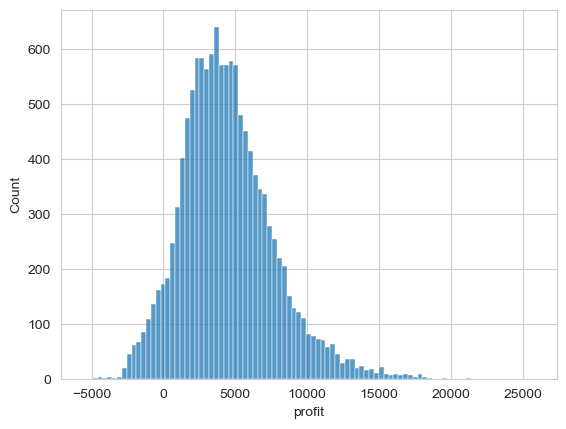

In [122]:
sns.histplot(df_a['profit'])

In [123]:
#Handle Negative Order Total
df_a[df_a['order_total'] < 0][[
    'order_id',
    'quantity',
    'unit_price',
    'order_total'
]]

,order_id,quantity,unit_price,order_total
73,4.471162e+09,1.0,114.52,-50.0
524,8.686094e+09,2.0,84.20,-50.0
2534,2.475155e+09,3.0,198.15,-50.0
3396,3.239614e+09,1.0,326.42,-50.0
4951,5.094990e+09,2.0,825.46,-50.0
6181,2.067086e+09,3.0,17.17,-50.0
6758,4.601715e+09,1.0,89.49,-50.0
6882,5.176018e+07,2.0,971.47,-50.0
7885,5.099152e+09,3.0,32.48,-50.0
8934,2.915284e+09,1.0,515.05,-50.0


In [124]:
df_a = df_a[
    df_a['order_total'] >= 0
]

In [125]:
(df_a['order_total'] < 0).sum()

np.int64(0)

In [126]:
df_a.shape

(12895, 43)

In [127]:
print("Negative Spend:",
      (df_a['spend'] < 0).sum())

print("Negative Revenue:",
      (df_a['revenue_generated'] < 0).sum())

print("Invalid Quantity:",
      (df_a['quantity'] <= 0).sum())

print("Negative Order Total:",
      (df_a['order_total'] < 0).sum())

print("Missing Values:",
      df_a.isnull().sum().sum())

print("Duplicates:",
      df_a.duplicated().sum())

Negative Spend: 0
Negative Revenue: 0
Invalid Quantity: 45
Negative Order Total: 0
Missing Values: 2870
Duplicates: 0


In [128]:
# removing negative quantities
df_a[df_a['quantity'] <= 0]['quantity'].value_counts()

quantity
-1.0    21
-5.0    12
 0.0    12
Name: count, dtype: int64

In [129]:
df_a = df_a[df_a['quantity'] > 0]

In [130]:
(df_a['quantity'] <= 0).sum()

np.int64(0)

In [131]:
# for 10k missing values 

missing = pd.DataFrame({
    'Missing_Count': df_a.isnull().sum(),
    'Missing_%': (df_a.isnull().sum()/len(df_a))*100
})

missing.sort_values(
    by='Missing_Count',
    ascending=False
).head(20)

,Missing_Count,Missing_%
customer_segment,343,2.674464
registration_date,330,2.573099
sentiment,328,2.557505
payment_method,270,2.105263
feedback_date,256,1.996101
area,256,1.996101
feedback_category,253,1.972710
delivery_status,216,1.684211
channel,193,1.504873
delay_minutes,189,1.473684


In [132]:
# date problem 
df_a[df_a['registration_date'].isnull()].head()

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,impressions,clicks,conversions,spend,revenue_generated,roas,delay_minutes,sla_breach,profit,profit_margin
118,3953251.0,9.411814e+09,62600289.0,3.0,Delivery,Negative,2023-09-25,66761643.0,Anand,695591.0,...,6370,604,70,3516.78,2866.20,3.100,5.0,1,-650.58,-22.698346
128,4364701.0,9.870610e+09,94033330.0,2.0,Product Quality,Negative,2024-02-08,96511007.0,Dindigul,470156.0,...,6955,317,78,3341.07,5741.39,3.730,-1.0,0,2400.32,41.807298
174,1801673.0,5.383262e+09,34588087.0,4.0,Product Quality,Neutral,2023-10-18,74212242.0,Allahabad,725534.0,...,4621,846,89,2010.23,4857.76,4.615,-4.0,0,2847.53,58.618170
176,9347337.0,8.787105e+09,81822935.0,4.0,Delivery,Positive,2024-05-07,22321208.0,Ballia,740752.0,...,7936,927,82,4318.97,7069.93,3.560,3.0,1,2750.96,38.910711
240,4669199.0,1.354097e+09,98687927.0,4.0,Product Quality,Positive,2023-06-21,67465084.0,Ratlam,549174.0,...,7568,537,80,4097.25,6494.20,2.810,2.0,1,2396.95,36.909088


In [133]:
df_a[df_a['feedback_date'].isnull()].head()

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,impressions,clicks,conversions,spend,revenue_generated,roas,delay_minutes,sla_breach,profit,profit_margin
55,261554.0,3.872982e+09,15484407.0,4.0,Delivery,Neutral,NaT,68159723.0,Orai,197279.0,...,4788,628,76,2603.20,2979.58,3.95,1.0,1,376.38,12.631982
122,1883777.0,5.853998e+09,94453274.0,3.0,Delivery,Negative,NaT,74195536.0,Amaravati,861407.0,...,7577,598,15,2804.30,9402.79,3.65,-3.0,0,6598.49,70.175873
196,4065348.0,8.833090e+08,71229024.0,4.0,App Experience,Neutral,NaT,16543242.0,Darbhanga,412653.0,...,3597,149,48,4273.24,5148.84,2.75,8.0,1,875.60,17.005772
320,4189141.0,9.554019e+09,6247821.0,4.0,App Experience,Positive,NaT,34897081.0,Shahjahanpur,647500.0,...,5986,993,71,1932.62,4548.25,3.60,-5.0,0,2615.63,57.508492
329,4048113.0,1.857227e+09,99301505.0,5.0,Product Quality,Positive,NaT,59141605.0,Motihari,58086.0,...,6993,807,80,2023.52,5974.74,2.80,4.0,1,3951.22,66.132083


In [134]:
df_a.drop(
    'date',
    axis=1,
    inplace=True
)

In [135]:
df_a.isnull().sum().sort_values(
    ascending=False
).head(10)

customer_segment        343
registration_date       330
sentiment               328
payment_method          270
feedback_date           256
area                    256
feedback_category       253
delivery_status         216
channel                 193
actual_delivery_time    189
dtype: int64

In [136]:
#Categorical Columns → Fill with Mode
cat_cols = [
    'customer_segment',
    'sentiment',
    'payment_method',
    'area',
    'feedback_category',
    'delivery_status',
    'channel'
]

for col in cat_cols:
    df_a[col].fillna(
        df_a[col].mode()[0],
        inplace=True
    )

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\1389062249.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a[col].fillna(


In [137]:
#registration_date --> Since you created:customer_tenure_days --> you need this column.
#Fill with median date:
median_reg = df_a['registration_date'].median()

df_a['registration_date'].fillna(
    median_reg,
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\3756129147.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['registration_date'].fillna(


In [138]:
#feedback date 
median_feedback = df_a['feedback_date'].median()

df_a['feedback_date'].fillna(
    median_feedback,
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\2810874060.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['feedback_date'].fillna(


In [139]:
#for actual delivery time 
df_a['actual_delivery_time'].fillna(
    df_a['promised_delivery_time'],
    inplace=True
)

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_32800\4078299869.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_a['actual_delivery_time'].fillna(


In [140]:
# recalculate delivery features 
df_a['delay_minutes'] = (
    df_a['actual_delivery_time']
    -
    df_a['promised_delivery_time']
).dt.total_seconds()/60

In [141]:
df_a['sla_breach'] = np.where(
    df_a['delay_minutes'] > 0,
    1,
    0
)

In [142]:
df_a.isnull().sum().sort_values(
    ascending=False
).head(10)

feedback_id            0
channel                0
delivery_status        0
order_total            0
payment_method         0
delivery_partner_id    0
store_id               0
campaign_id            0
campaign_name          0
target_audience        0
dtype: int64

In [143]:
(df_a['profit']<0).sum() # orders which dont compute to profit #loss making 

np.int64(810)

In [144]:
# standardization profit 
df_a['profit'].std()

3270.970719022126

In [145]:
# creating profit margin 
df_a['profit_margin']=(
    df_a['profit']
    /df_a['revenue_generated']
)*100

In [146]:
df_a['profit_margin'].describe()

count    1.282500e+04
mean             -inf
std               NaN
min              -inf
25%      4.745569e+01
50%      6.023633e+01
75%      6.735255e+01
max      1.000000e+02
Name: profit_margin, dtype: float64

In [147]:
# extract order hour 
df_a['order_hour'] = df_a['order_date'].dt.hour

In [148]:
# creating day time 
df_a['day_name'] = df_a['order_date'].dt.day_name()

In [149]:
# creating peak period 
def peak_period(hour):
    if 7 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 16:
        return 'Lunch'
    elif 16 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

In [150]:
df_a['peak_period'] = (
    df_a['order_hour']
    .apply(peak_period)
)

In [151]:
# validating peak periods
df_a['peak_period'].value_counts()

peak_period
Night      3774
Evening    3306
Lunch      3160
Morning    2585
Name: count, dtype: int64

In [152]:
# checking new features 
df_a[[
    'delay_minutes',
    'sla_breach',
    'profit',
    'order_hour',
    'day_name',
    'peak_period'
]].head()

,delay_minutes,sla_breach,profit,order_hour,day_name,peak_period
0,-5.0,0,3345.90,8,Wednesday,Morning
1,2.0,1,1731.77,13,Tuesday,Lunch
2,4.0,1,-1903.23,13,Monday,Lunch
3,-1.0,0,-667.79,16,Friday,Evening
4,1.0,1,6062.82,5,Monday,Night


EDA EXPLORATORY DATA ANALYSIS 

In [153]:
# EDA SECTION 1 SLA AND DELIVERY PERFORMANCE 
#  overall sla breach rate 
df_a['sla_breach'].mean()*100

np.float64(45.20077972709552)

<Axes: xlabel='sla_breach', ylabel='count'>

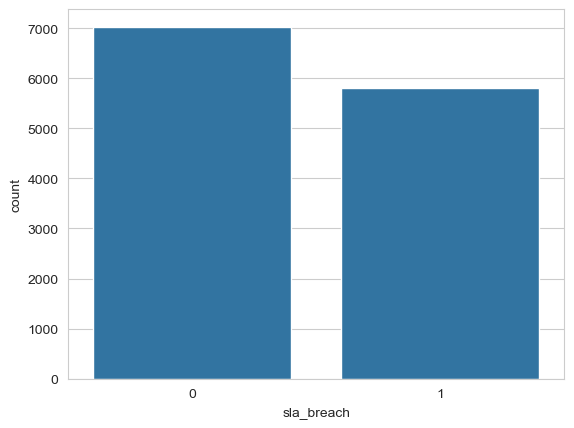

In [154]:
sns.countplot(
    x='sla_breach',
    data=df_a
)

In [155]:
# sla breach by store 
store_sla = (
    df_a.groupby('store_id')['sla_breach']
    .mean()
    .sort_values(ascending=False)
)

store_sla

store_id
9998.0    1.0
9111.0    1.0
8492.0    1.0
2711.0    1.0
6036.0    1.0
         ... 
5060.0    0.0
5061.0    0.0
5062.0    0.0
5065.0    0.0
5201.0    0.0
Name: sla_breach, Length: 7626, dtype: float64

<Axes: xlabel='store_id'>

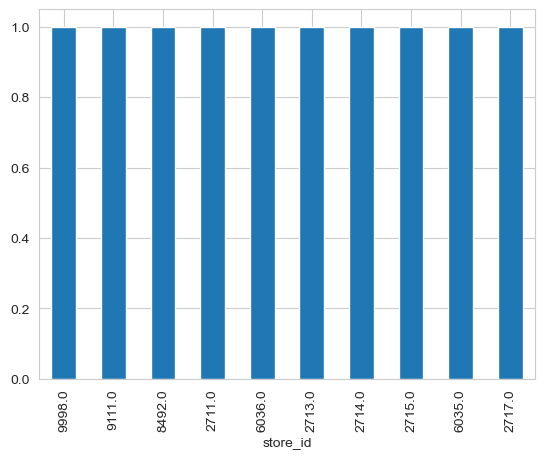

In [156]:
store_sla.head(10).plot(kind='bar')

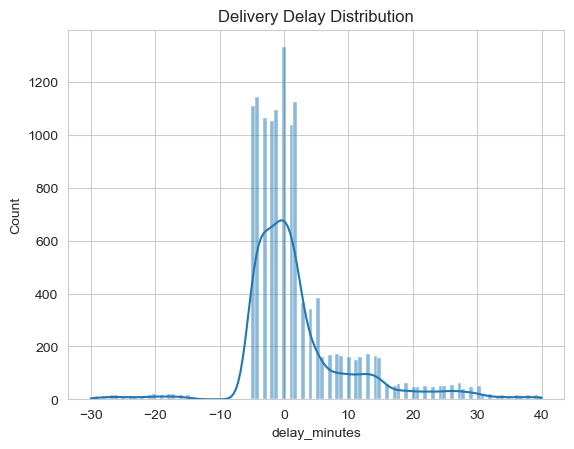

In [157]:
#delay distribution
sns.histplot(
    df_a['delay_minutes'],
    kde=True
)

plt.title('Delivery Delay Distribution')
plt.show()


In [ ]:
#delay by customer segment
sns.barplot(
    x='customer_segment',
    y='delay_minutes',
    data=df_a
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
# delay by peak period 
sns.boxplot(
    x='peak_period',
    y='delay_minutes',
    data=df_a
)

In [ ]:
# delay partner performance 
partner_delay = (
    df_a.groupby('delivery_partner_id')
    ['delay_minutes']
    .mean()
    .sort_values(ascending=False)
)

partner_delay

In [ ]:
# EDA SECTION 2  PROFITABILITY ANALYSIS 
# profit distribution 
sns.histplot(
    df_a['profit'],
    kde=True
)


In [ ]:
# profit by campaign 
campaign_profit = (
    df_a.groupby('campaign_name')['profit']
    .mean()
    .sort_values(ascending=False)
)

campaign_profit

In [ ]:
campaign_profit.plot(kind='bar')

In [ ]:
#channel wise profit
channel_profit = df_a.groupby(
    'channel'
)['profit'].sum().sort_values(
    ascending=False
)

channel_profit.plot(kind='bar')

plt.title('Profit by Channel')
plt.show()

In [ ]:
# spend vs revenue analysis 
sns.scatterplot(
    x='spend',
    y='revenue_generated',
    data=df_a
)

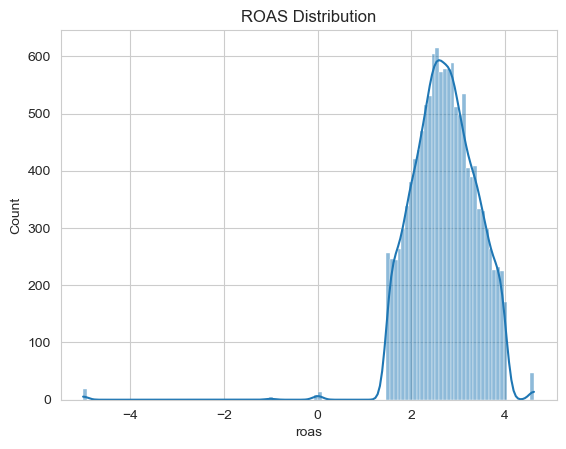

In [473]:
#roas distribution
sns.histplot(
    df_a['roas'],
    kde=True
)

plt.title('ROAS Distribution')
plt.show()

<Axes: xlabel='profit_margin', ylabel='Count'>

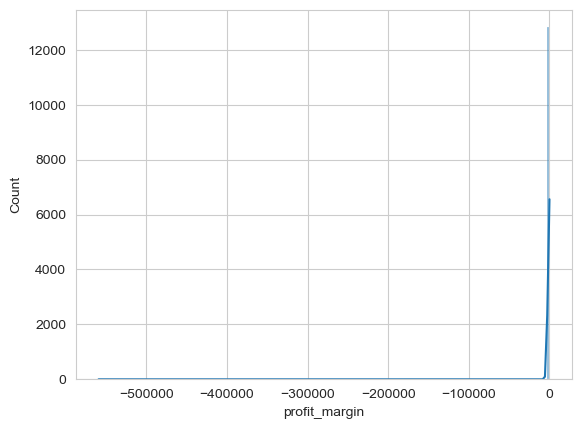

In [454]:
# profit margin analysis s
sns.histplot(
    df_a['profit_margin'],
    kde=True
)

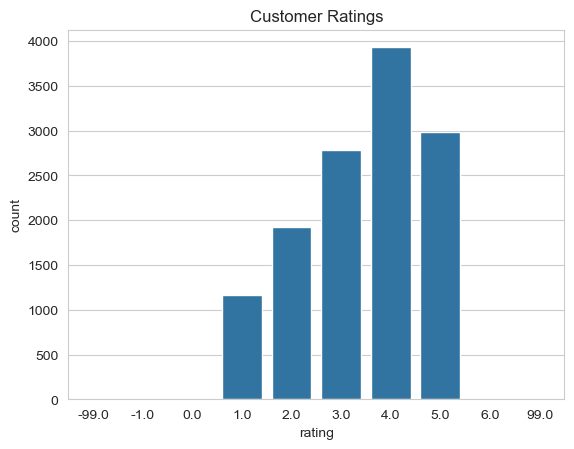

In [474]:
# EDA SECTION 3 CUSTOMER EXPERIENCE  
# customer rating distribution
sns.countplot(
    x='rating',
    data=df_a
)

plt.title('Customer Ratings')
plt.show()

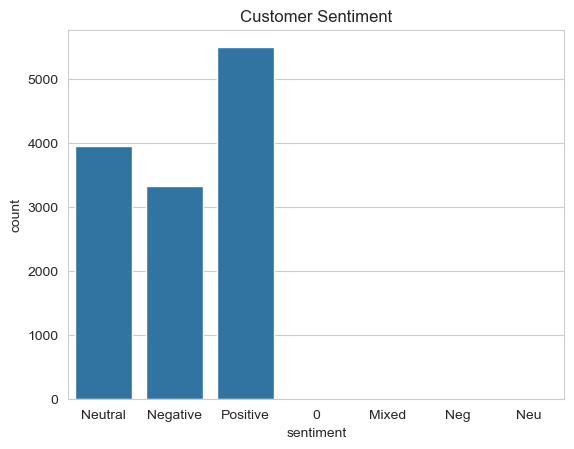

In [476]:
#sentiment distribution
sns.countplot(
    x='sentiment',
    data=df_a
)

plt.title('Customer Sentiment')
plt.show()


<Axes: xlabel='delay_minutes', ylabel='rating'>

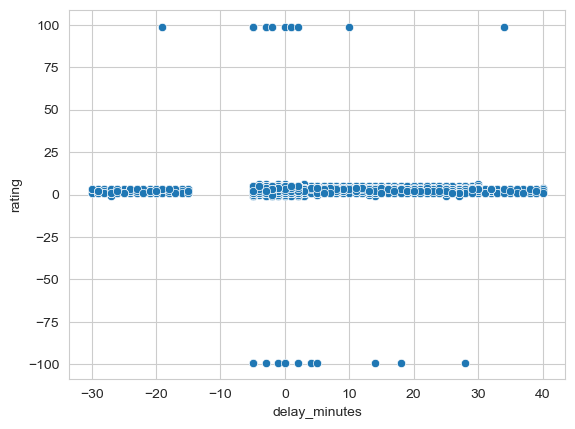

In [477]:
#Delay vs Customer Rating
sns.scatterplot(
    x='delay_minutes',
    y='rating',
    data=df_a
)

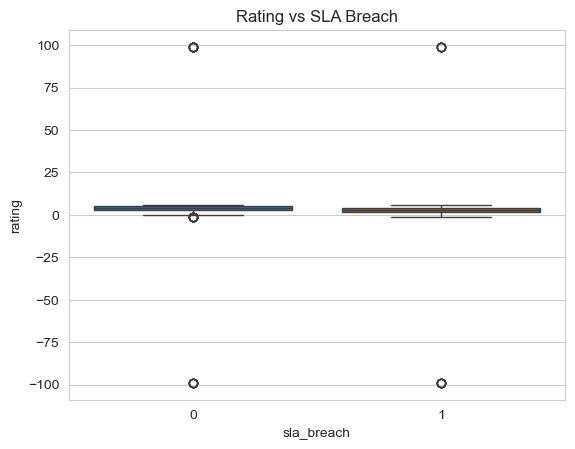

In [478]:
#rating vs sla breach
sns.boxplot(
    x='sla_breach',
    y='rating',
    data=df_a
)

plt.title('Rating vs SLA Breach')
plt.show()

In [457]:
# feedback category analysis 
df_a['feedback_category'].value_counts()

feedback_category
Customer Service    2790
Delivery            2523
App Experience      2512
Product Quality     2507
Pricing             1268
Packaging           1250
Name: count, dtype: int64

<Axes: xlabel='order_hour', ylabel='count'>

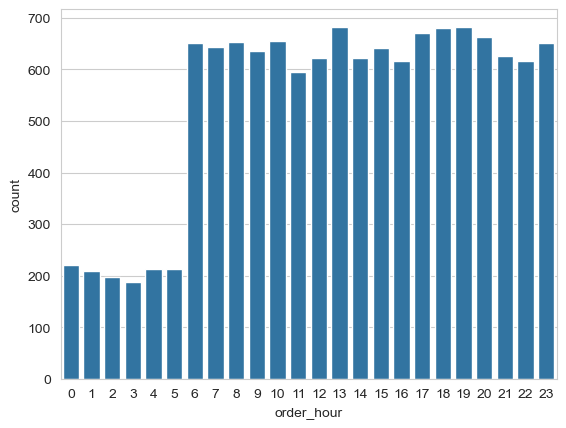

In [458]:
#EDA SECTION 4 OPERATIONAL LOAD ANALYSIS 
# order by hour 
sns.countplot(
    x='order_hour',
    data=df_a
)

<Axes: xlabel='day_name', ylabel='count'>

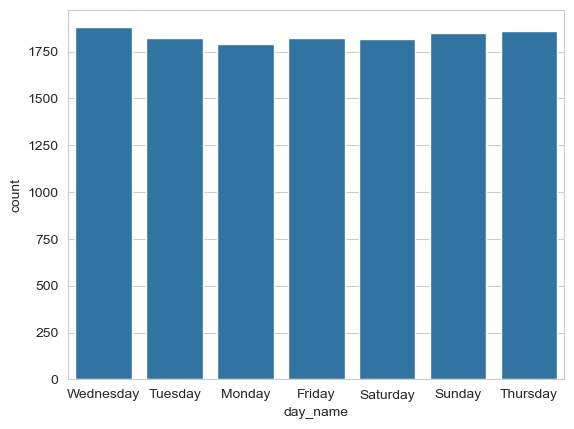

In [459]:
# oreder by day 
sns.countplot(
    x='day_name',
    data=df_a
)

<Axes: xlabel='peak_period', ylabel='count'>

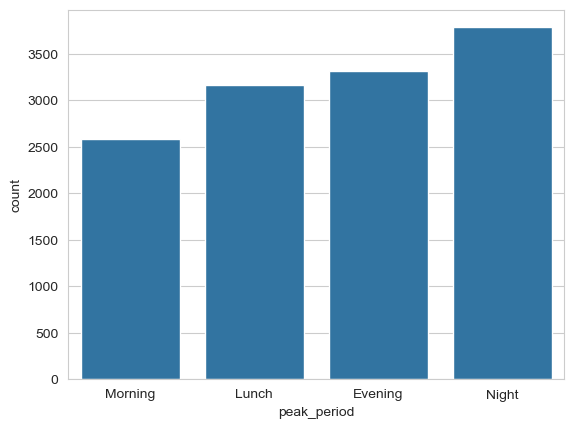

In [460]:
# peak period distribution 
sns.countplot(
    x='peak_period',
    data=df_a
)

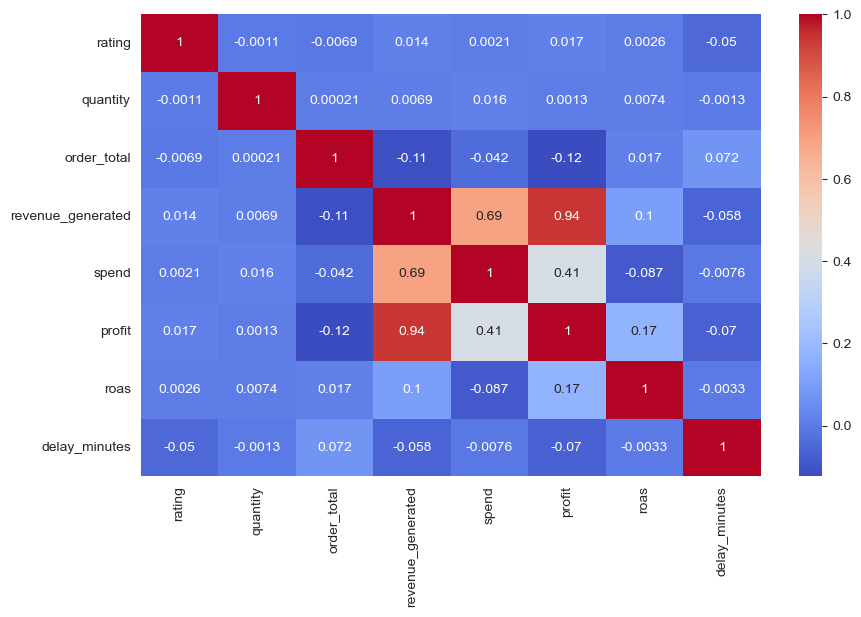

In [479]:
#EDA SECTION 5: FINAL BUSINESS RELATIONSHIPS
#Correlation Heatmap
num_cols = [
    'rating',
    'quantity',
    'order_total',
    'revenue_generated',
    'spend',
    'profit',
    'roas',
    'delay_minutes'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df_a[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [480]:
#Campaign Performance Matrix
campaign_perf = df_a.groupby(
    'campaign_name'
)[[
    'profit',
    'roas',
    'revenue_generated'
]].mean()

campaign_perf.sort_values(
    by='profit',
    ascending=False
).head(10)

,profit,roas,revenue_generated
campaign_name,,,
Diwali Bonanza,6064.187053,2.744354,9628.865695
Festive Essentials Sale,5757.135368,2.723635,9198.558252
Free Delivery Campaign,5746.793573,2.759557,9117.481136
Instant Delivery Offer,5660.495714,2.746905,8994.722440
Midnight Deals,5640.914407,2.683936,9113.576201
Holi Special,5589.795667,2.666667,9019.206636
Fresh Fruits Week,5584.344474,2.671398,8937.164375
Daily Needs Offer,5496.021855,2.641635,8915.830409
First Order Discount,5475.149756,2.653262,8966.500610


In [461]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12850 entries, 0 to 12999
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   feedback_id             12850 non-null  float64       
 1   order_id                12850 non-null  float64       
 2   customer_id             12850 non-null  float64       
 3   rating                  12850 non-null  float64       
 4   feedback_category       12850 non-null  object        
 5   sentiment               12850 non-null  object        
 6   feedback_date           12850 non-null  datetime64[ns]
 7   customer_id.1           12850 non-null  float64       
 8   area                    12850 non-null  object        
 9   pincode                 12850 non-null  float64       
 10  registration_date       12850 non-null  datetime64[ns]
 11  customer_segment        12850 non-null  object        
 12  total_orders            12850 non-null  float64    

In [481]:
df_a.shape


(12850, 45)

In [482]:
df_a.head()

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id.1,area,pincode,...,spend,revenue_generated,roas,delay_minutes,sla_breach,profit,profit_margin,order_hour,day_name,peak_period
0,2234710.0,1.961864e+09,30065862.0,4.0,Delivery,Neutral,2024-07-17,97475543.0,Udupi,321865.0,...,1431.85,4777.75,3.60,-5.0,0,3345.90,70.030872,8,Wednesday,Morning
1,5450964.0,1.549770e+09,9573071.0,3.0,App Experience,Negative,2024-05-28,22077605.0,Aligarh,149394.0,...,4506.34,6238.11,2.98,2.0,1,1731.77,27.761133,13,Tuesday,Lunch
2,482108.0,9.185164e+09,45477575.0,3.0,App Experience,Neutral,2024-09-23,47822591.0,Begusarai,621411.0,...,4524.23,2621.00,2.95,4.0,1,-1903.23,-72.614651,13,Monday,Lunch
3,4823104.0,9.644739e+09,88067569.0,4.0,App Experience,Neutral,2023-11-24,79726146.0,Kozhikode,826054.0,...,3622.79,2955.00,2.84,-1.0,0,-667.79,-22.598646,16,Friday,Evening
4,3537464.0,5.427684e+09,83298567.0,3.0,Delivery,Negative,2023-11-20,57102800.0,Ichalkaranji,730539.0,...,2888.99,8951.81,2.22,1.0,1,6062.82,67.727309,5,Monday,Night


In [483]:
df_a.columns


Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_category',
       'sentiment', 'feedback_date', 'customer_id.1', 'area', 'pincode',
       'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value', 'order_id.1', 'product_id', 'quantity', 'unit_price',
       'order_id.2', 'customer_id.2', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'campaign_id',
       'campaign_name', 'target_audience', 'channel', 'impressions', 'clicks',
       'conversions', 'spend', 'revenue_generated', 'roas', 'delay_minutes',
       'sla_breach', 'profit', 'profit_margin', 'order_hour', 'day_name',
       'peak_period'],
      dtype='object')

In [484]:
df_a.to_csv(
    'cleaned_quick_commerce_data.csv',
    index=False
)

In [485]:
df_a.to_excel(
    'cleaned_quick_commerce_data.xlsx',
    index=False
)